In [2]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [3]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 24}

plt.rc( 'font',**font);
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [4]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,12))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'distance_at_head_turn_2_index'] = np.nan
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
            df.at[ind,'num_turn'] = 0
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.array(peaks).astype(object)
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'num_turn'] = len(peaks)
def towards_away_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_corner_angle_velocity[:int(row.obstacle_ind)], width=1,height=(2,12))
        neg_peaks, neg_prop = find_peaks((row.head_corner_angle_velocity[:int(row.obstacle_ind)])*-1, width=1,height=(2,12))
        if len(pos_peaks) == 0:
            df.at[ind,'towards_num_turn'] = 0
        elif len(neg_peaks) == 0: 
            df.at[ind,'away_num_turn'] = 0  
        else:
            df.at[ind,'towards_num_turn'] = len(pos_peaks)
            df.at[ind,'away_num_turn'] = len(neg_peaks)
def right_left_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)], width=2,height=(3,12))
        neg_peaks, neg_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)]*-1, width=2,height=(3,12))
        
        if row.odd == 'right':
            df.at[ind,'right_num_turn'] = len(neg_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]
            df.at[ind,'left_num_turn'] = len(pos_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
        elif row.odd == 'left':
            df.at[ind,'right_num_turn'] = len(pos_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
            df.at[ind,'left_num_turn'] = len(neg_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]
def first_occurrence_indices(arr):
    unique_values, first_indices = np.unique(arr, return_index=True)
    sorted_indices = np.sort(first_indices)
    return sorted_indices

In [5]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
heading_calcs(joint)
get_head_angle(joint)
head_angle_velocity(joint)
angular_velocity_head_corner(joint)
distance_at_head_turn_2(joint)
towards_away_turns(joint)
right_left_turns(joint)
#con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
#long_con,short_con,middle_con = create_df_by_type(con_df)

corner
port


In [1]:
row.lateral_error[0]

NameError: name 'row' is not defined

In [6]:
def intial_lateral_error(df):
    df = drop_nans_in_columns(df,'lateral_error')
    for ind, row in df.iterrows():
        intial_lateral_error = row.lateral_error[0]
        df.at[ind,'intial_lateral_error'] = intial_lateral_error

In [625]:
intial_lateral_error(joint)

In [782]:
calculate_speed(joint)

In [7]:

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)

In [8]:
test = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint.h5")
test1 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint1.h5")
joint = pd.concat([test,test1])

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)

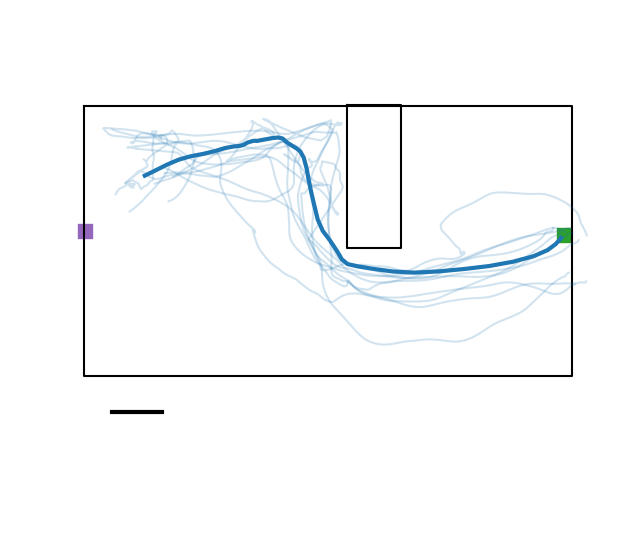

In [468]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'towards')&(long_nostart.obstacle_cross == True)&(long_nostart.tortuosity >1.5)]
#light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light.sample(10)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')
ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

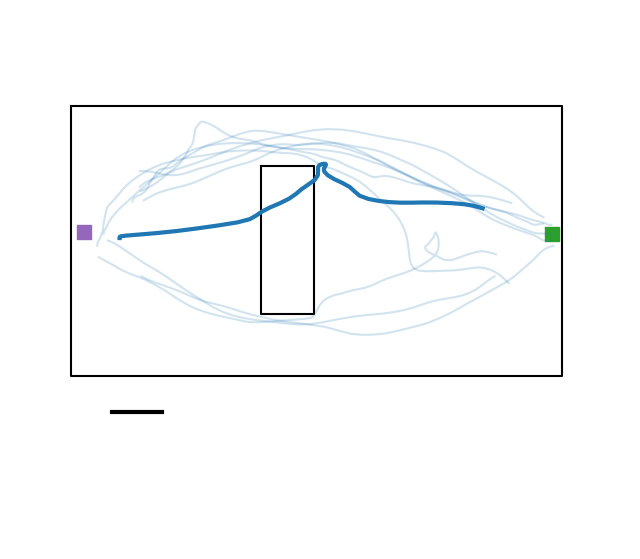

In [598]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = middle_nostart[(middle_nostart.obstacle_cluster == 2)&(middle_nostart.task == 'oa')&(middle_nostart.turn_to_obstacle == 'away')&(middle_nostart.obstacle_cross == True)&(middle_nostart.date_index >= 3)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light.sample(10)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')
ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

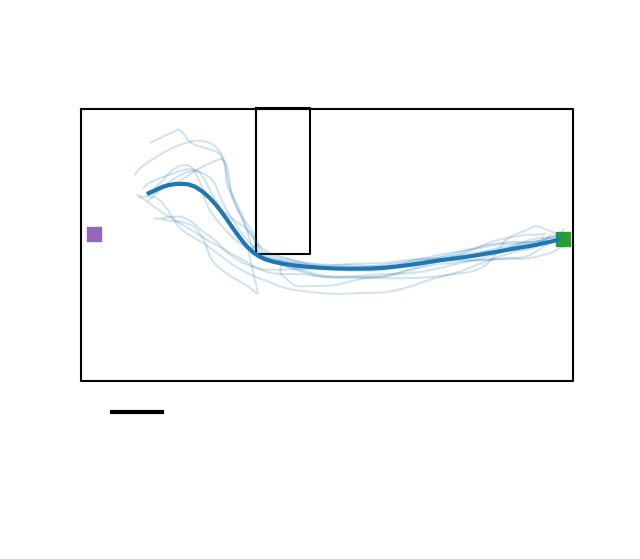

In [878]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = short_nostart[(short_nostart.obstacle_cluster == 0)&(short_nostart.task == 'oa')&(short_nostart.turn_to_obstacle == 'towards')&(short_nostart.obstacle_cross == True)&(short_nostart.date_index >= 3)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light.sample(10)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')
#ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(38,38),c ='black', linewidth = 3)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\short_light_traces_towards.pdf',dpi = 300, transparent=True)

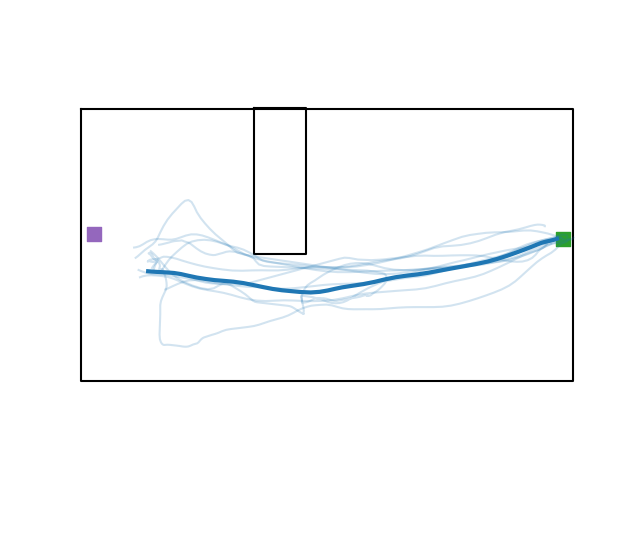

In [639]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = short_nostart[(short_nostart.obstacle_cluster == 0)&(short_nostart.task == 'oa')&(short_nostart.turn_to_obstacle == 'towards')&(short_nostart.obstacle_cross == True)&(short_nostart.date_index >= 3)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light.sample(10)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')
#ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

Text(0.5, 0.98, 'short towards light')

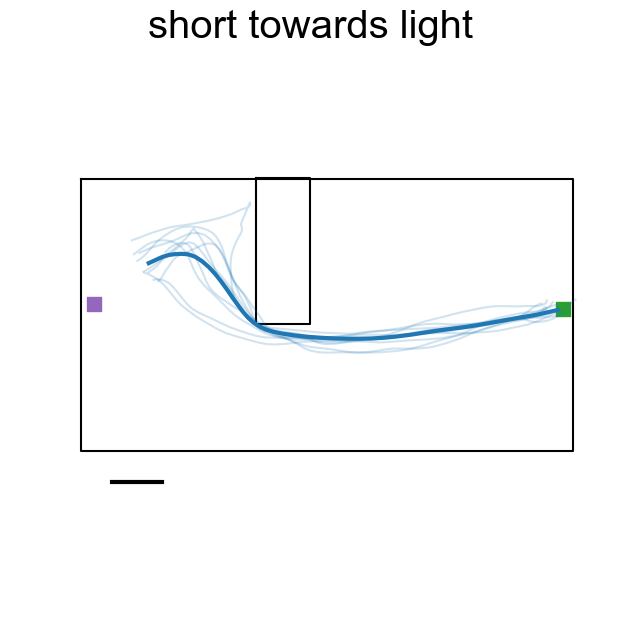

In [28]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = short_nostart[(short_nostart.obstacle_cluster == 0)&(short_nostart.task == 'oa')&(short_nostart.turn_to_obstacle == 'towards')&(short_nostart.obstacle_cross == True)&(short_nostart.date_index >= 3)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light.sample(10)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')
#ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(38,38),c ='black', linewidth = 3)

fig.suptitle('short towards light')

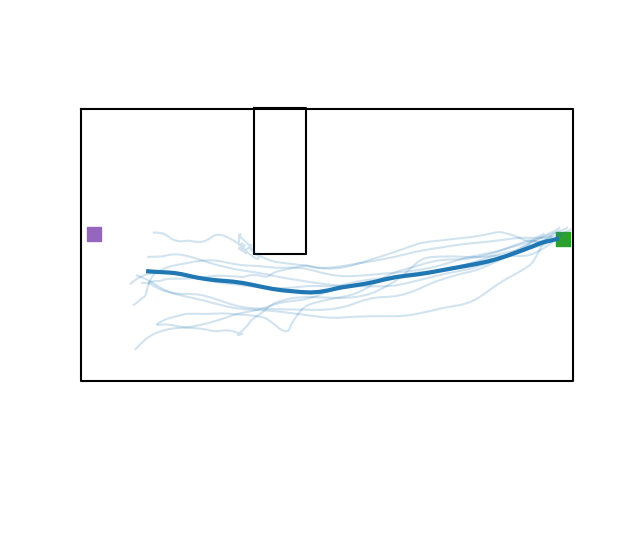

In [23]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = short_nostart[(short_nostart.obstacle_cluster == 0)&(short_nostart.task == 'oa')&(short_nostart.turn_to_obstacle == 'away')&(short_nostart.obstacle_cross == True)&(short_nostart.date_index >= 3)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light.sample(10)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')
#ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\short_light_traces_away.pdf',dpi = 300, transparent=True)

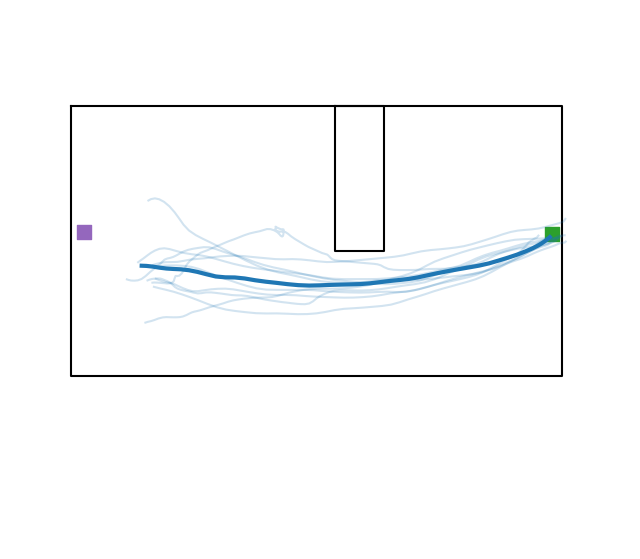

In [101]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'away')&(long_nostart.obstacle_cross == True)&(long_nostart.date_index >= 3)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_away = light.sample(10)
for ind,row in light_sample_away.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')
#ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\light_traces_away.pdf',dpi = 300, transparent=True)

Dark traces towards

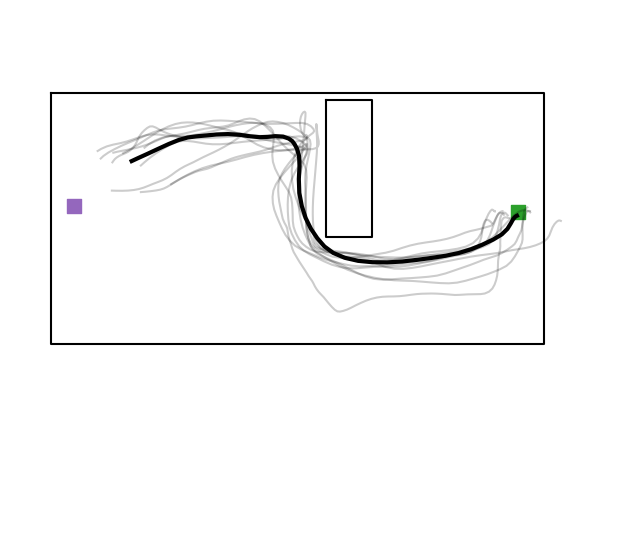

In [59]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
dark = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')&(long.obstacle_cross == True)&(long.date_index == 2)]
dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(dark,ax)
ob_x,ob_y = plot_orginal_obstacle(dark,ax,5)
dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))
ax.plot(dark_nose_x,dark_nose_y,linewidth = 3,color = 'black')
#dark_sample_towards = dark.sample(10)
for ind,row in dark_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.plot((10,15),(40,40),c ='black', linewidth = 3)

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\dark_traces_towards.pdf',dpi = 300, transparent=True)

Text(0.5, 0.98, 'short towards dark')

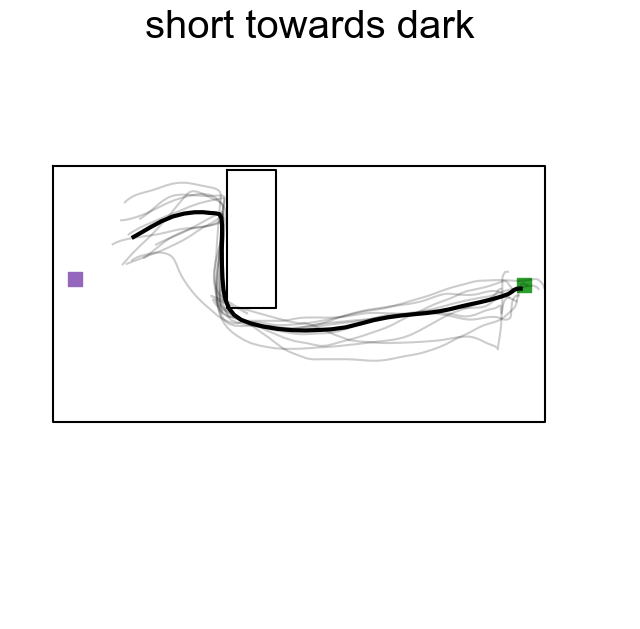

In [29]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
dark = short_nostart[(short_nostart.obstacle_cluster == 0)&(short_nostart.task == 'oadark')&(short_nostart.turn_to_obstacle == 'towards')&(short_nostart.obstacle_cross == True)]
dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(dark,ax)
ob_x,ob_y = plot_orginal_obstacle(dark,ax,5)
dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))
ax.plot(dark_nose_x,dark_nose_y,linewidth = 3,color = 'black')
dark_sample_towards = dark.sample(10)
for ind,row in dark_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
fig.suptitle('short towards dark')
#ax.plot((10,15),(40,40),c ='black', linewidth = 3)
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\short_dark_traces_towards.pdf',dpi = 300, transparent=True)


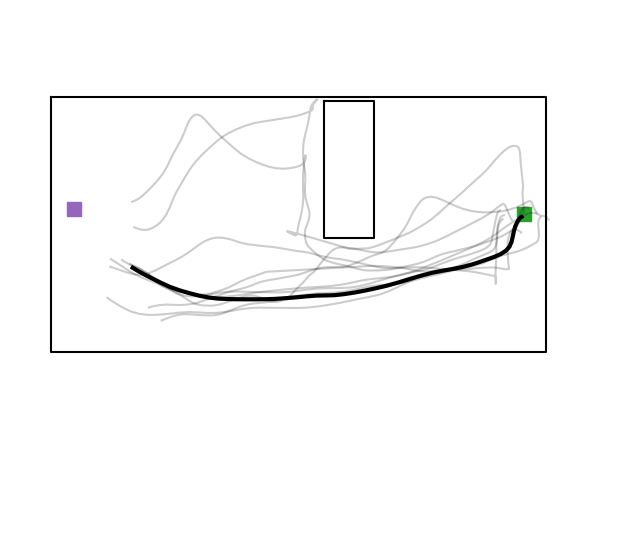

In [58]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
dark = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oadark')&(long_nostart.turn_to_obstacle == 'away')&(long_nostart.obstacle_cross == True)]
dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(dark,ax)
ob_x,ob_y = plot_orginal_obstacle(dark,ax,5)
dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))
ax.plot(dark_nose_x,dark_nose_y,linewidth = 3,color = 'black')
dark_sample_away= dark.sample(10)
for ind,row in dark_sample_away.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.plot((10,15),(40,40),c ='black', linewidth = 3)

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\dark_traces_away.pdf',dpi = 300, transparent=True)

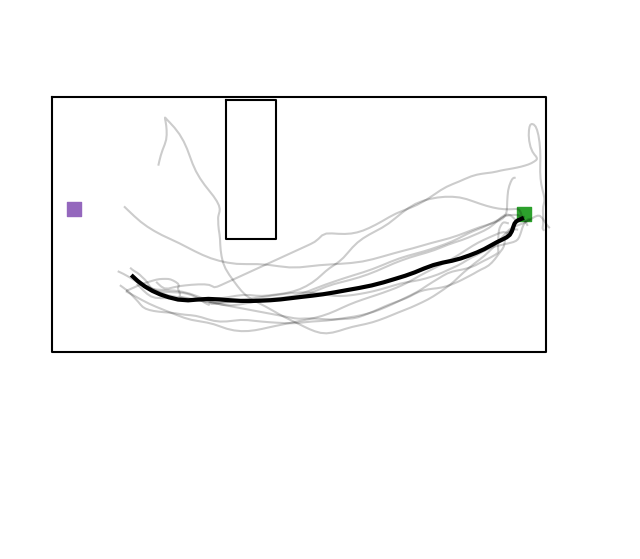

In [71]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
dark = short_nostart[(short_nostart.obstacle_cluster == 0)&(short_nostart.task == 'oadark')&(short_nostart.turn_to_obstacle == 'away')&(short_nostart.obstacle_cross == True)]
dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(dark,ax)
ob_x,ob_y = plot_orginal_obstacle(dark,ax,5)
dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))
ax.plot(dark_nose_x,dark_nose_y,linewidth = 3,color = 'black')
dark_sample_towards = dark.sample(10)
for ind,row in dark_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.plot((10,15),(40,40),c ='black', linewidth = 3)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\short_dark_traces_away.pdf',dpi = 300, transparent=True)

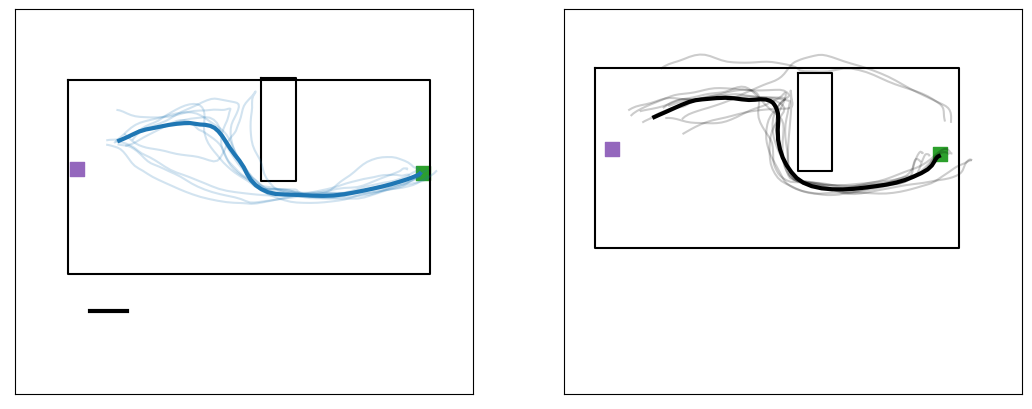

In [14]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
light = long[(long.obstacle_cluster == 1)&(long.task == 'oa')&(long.turn_to_obstacle == 'towards')&(long.obstacle_cross == True)&(long.date_index == 5)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]

dark = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')&(long.obstacle_cross == True)&(long.date_index == 2)]

dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
fig,ax = plt.subplots(1,2,figsize=(13,5),)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

plot_arena(light,ax[0])
plot_arena(dark,ax[1])

ob_x,ob_y = plot_orginal_obstacle(light,ax[0],5)
ob_x2,ob_y2 = plot_orginal_obstacle(dark,ax[1],5)

dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))

light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))

ax[1].plot(dark_nose_x,dark_nose_y,color = 'black',linewidth = 3)
ax[0].plot(light_nose_x,light_nose_y,linewidth = 3)

light_sample = light.sample(10)
for ind,row in light_sample.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(x,y,alpha = .2 ,c = 'tab:blue')

dark_sample = dark.sample(10)
for ind,row2 in dark_sample.iterrows():
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    ax[1].plot(x1,y2,alpha = .2 ,c = 'black')

ax[0].plot((10,15),(40,40),c ='black', linewidth = 3)

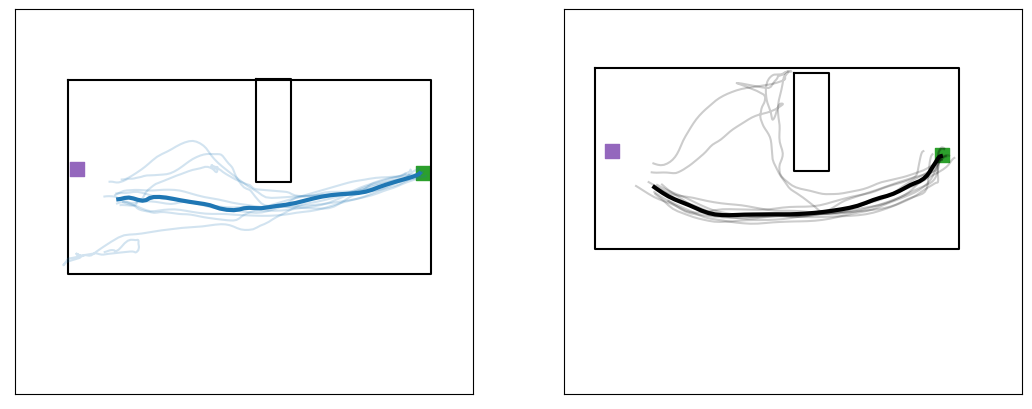

In [10]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
light = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'away')&(long_nostart.obstacle_cross == True)&(long_nostart.date_index == 5)]
light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
#light = light[light.linearity >= .8]

dark = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oadark')&(long_nostart.turn_to_obstacle == 'away')&(long_nostart.obstacle_cross == True)&(long_nostart.date_index == 2)]

dark = dark[dark['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
#dark = dark[dark.linearity >= .8]
fig,ax = plt.subplots(1,2,figsize=(13,5),)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

plot_arena(light,ax[0])
plot_arena(dark,ax[1])

ob_x,ob_y = plot_orginal_obstacle(light,ax[0],5)
ob_x2,ob_y2 = plot_orginal_obstacle(dark,ax[1],5)

dark_nose_x = smooth(get_median_of_df(dark,'ts_nose_x_cm',50))
dark_nose_y = smooth(get_median_of_df(dark,'ts_nose_y_cm',50))

light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))

ax[1].plot(dark_nose_x,dark_nose_y,color = 'black',linewidth = 3)
ax[0].plot(light_nose_x,light_nose_y,linewidth = 3)

light_sample = light
for ind,row in light_sample.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(x,y,alpha = .2 ,c = 'tab:blue')

dark_sample = dark
for ind,row2 in dark_sample.iterrows():
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    ax[1].plot(x1,y2,alpha = .2 ,c = 'black')

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\light_dark_traces3_away.pdf',dpi = 300)


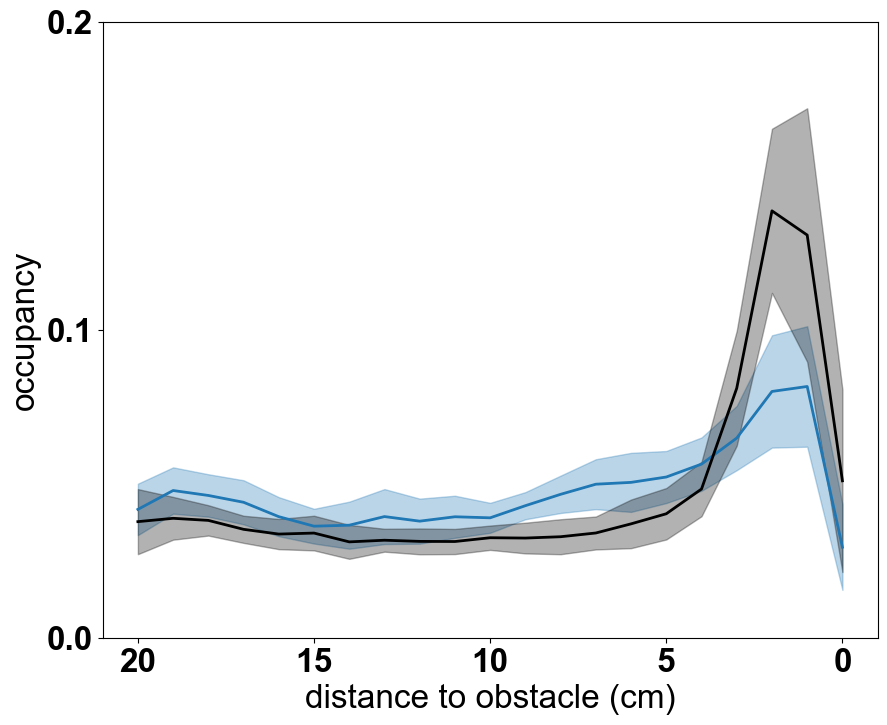

In [10]:
xnew =  np.arange(0, 21, 1)
data = pd.concat([long])
#data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts/sum(light_counts))
ax.plot(xnew, light_hist, 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts/sum(dark_counts))
ax.plot(xnew, dark_hist, 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    dark_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')   
ax.set_xticks([20,15,10,5,0])  
ax.set_yticks([.20,.1,.0])
ax.set_ylabel('occupancy')  
ax.set_xlabel('distance to obstacle (cm)')
ax.invert_xaxis()

#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\long_occupancy_towards.pdf',dpi = 300, transparent=True)

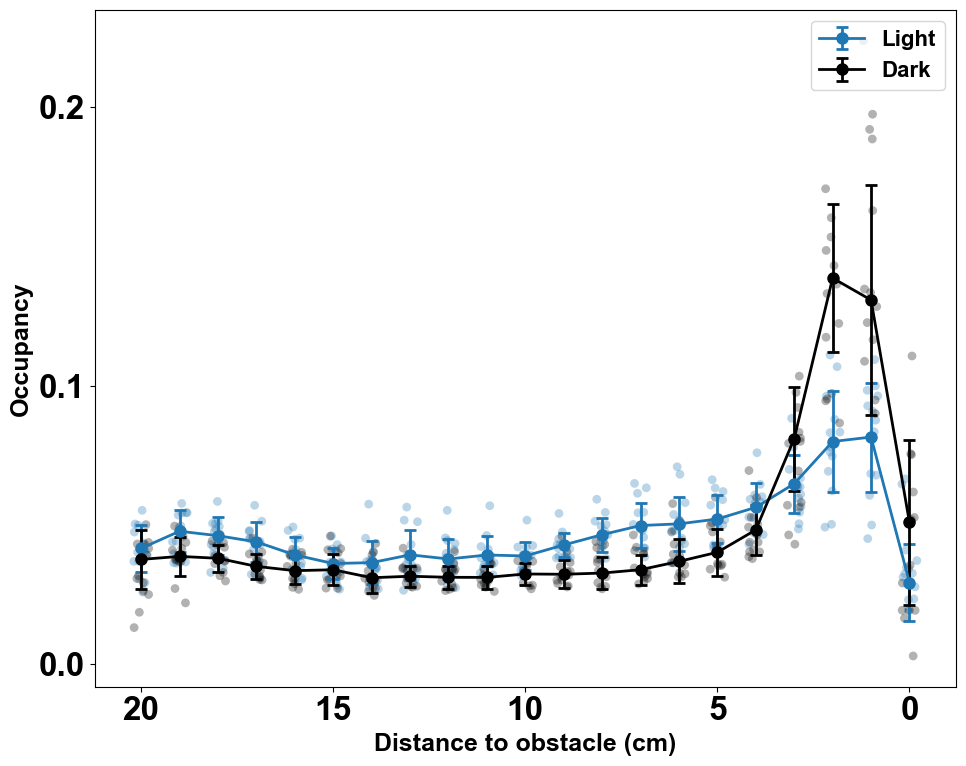

In [ ]:
xnew = np.arange(0, 21, 1)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []  # To store individual animal points

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []  # To store individual animal points

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='Light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='Dark')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('Occupancy', fontsize=18)
ax.set_xlabel('Distance to obstacle (cm)', fontsize=18)
ax.invert_xaxis()

# Add grid lines for better readability
#ax.grid(True, linestyle=':', alpha=0.3)

# Legend
ax.legend(loc='upper right', fontsize=16, framealpha=0.8)

plt.tight_layout()
plt.show()

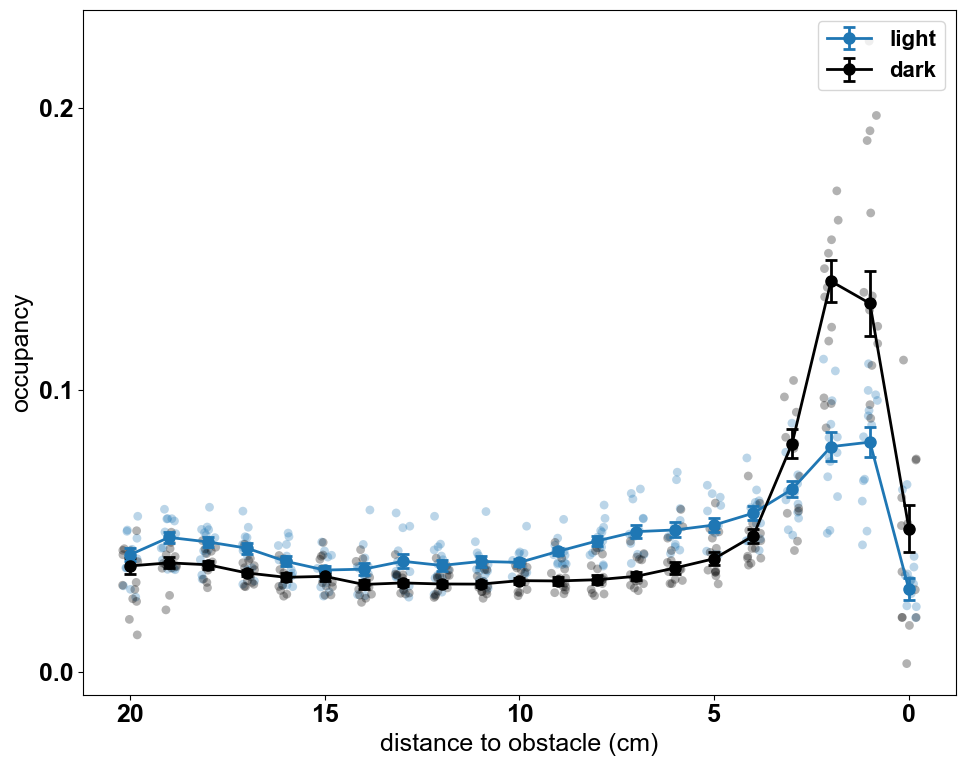

In [45]:
xnew = np.arange(0, 21, 1)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []  # To store individual animal points

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []  # To store individual animal points

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=16, framealpha=0.8)

plt.tight_layout()
plt.show()

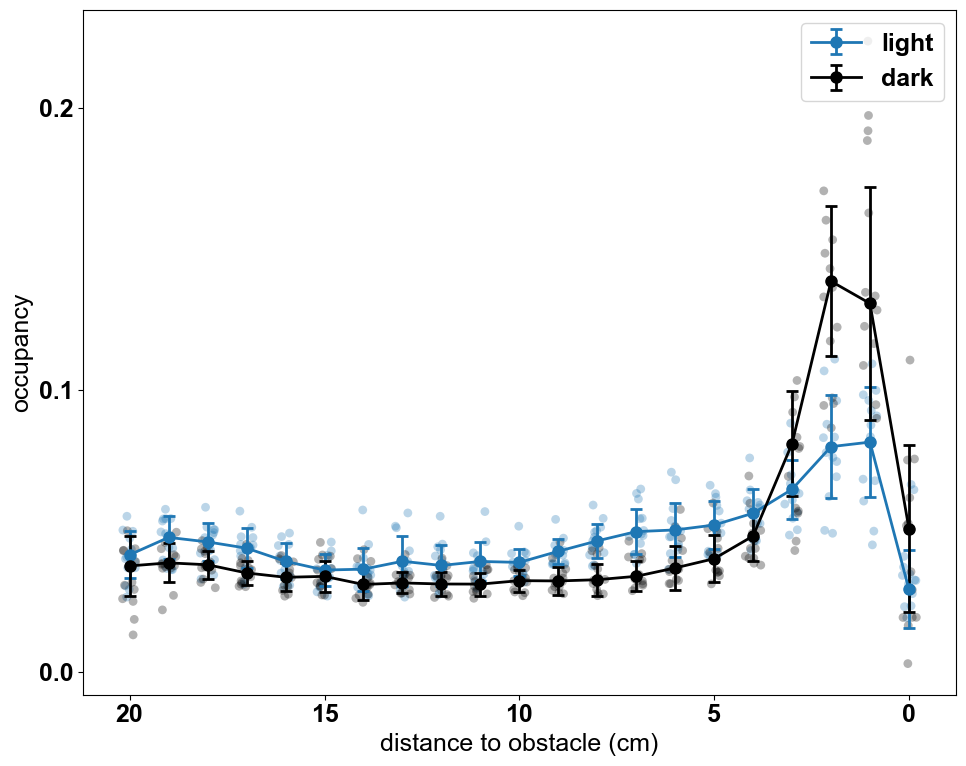

In [52]:
xnew = np.arange(0, 21, 1)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=18)  # lowercase
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)  # lowercase
ax.invert_xaxis()

# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

In [1]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['goal_angle_to_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40])
ax.set_ylabel('heading to the goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=32, framealpha=0.8)

# Grid lines for readability


plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "bold"

NameError: name 'plt' is not defined

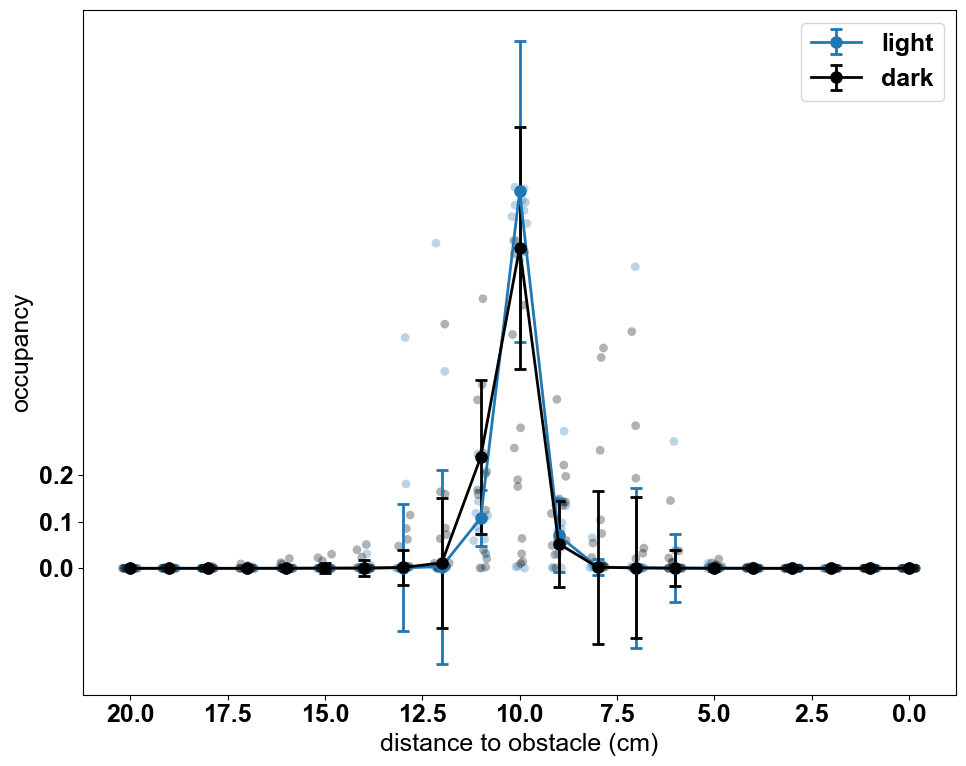

In [57]:
xnew = np.arange(0, 21, 1)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.head_angle_velocity.to_numpy())

light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.head_angle_velocity.to_numpy())
   
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.head_angle_velocity.to_numpy())

dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.head_angle_velocity.to_numpy())
    
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
#ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=18)  # lowercase
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)  # lowercase
ax.invert_xaxis()

# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

(array([ 2371.,  5346., 11568., 22814., 38251., 35074., 19621., 10351.,
         5064.,  2453.]),
 array([-500., -400., -300., -200., -100.,    0.,  100.,  200.,  300.,
         400.,  500.]),
 <BarContainer object of 10 artists>)

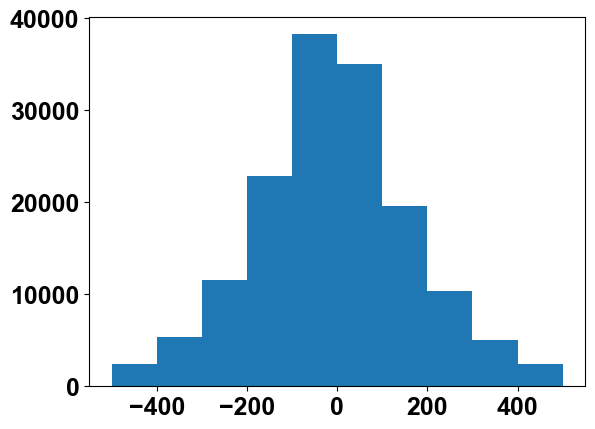

In [62]:
light_dist = flatten_list_of_arrays(dark.head_angle_velocity.to_numpy())
plt.hist(light_dist*60,range=(-500,+500))

(array([ 2169.,  5724., 15290., 34577., 61892., 58094., 31253., 13723.,
         5702.,  2185.]),
 array([-500., -400., -300., -200., -100.,    0.,  100.,  200.,  300.,
         400.,  500.]),
 <BarContainer object of 10 artists>)

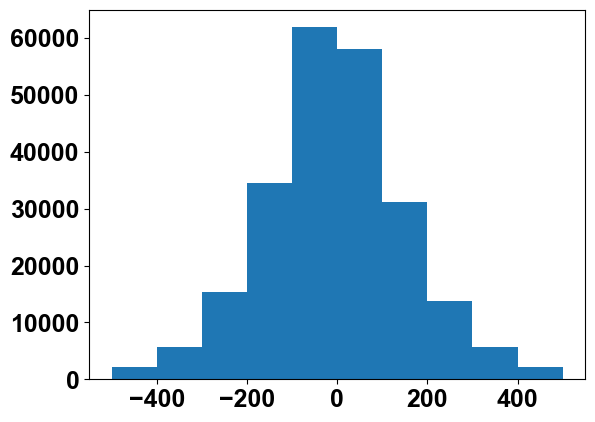

In [61]:
light_dist = flatten_list_of_arrays(light.head_angle_velocity.to_numpy())
plt.hist(light_dist*60,range=(-500,+500))

(array([14404., 15932.,  6603.,  5441.,  5225.,  5025.,  5038.,  5368.,
         5825.,  5994.]),
 array([2.72712475e-05, 2.00001380e+00, 4.00000032e+00, 5.99998685e+00,
        7.99997338e+00, 9.99995990e+00, 1.19999464e+01, 1.39999330e+01,
        1.59999195e+01, 1.79999060e+01, 1.99998925e+01]),
 <BarContainer object of 10 artists>)

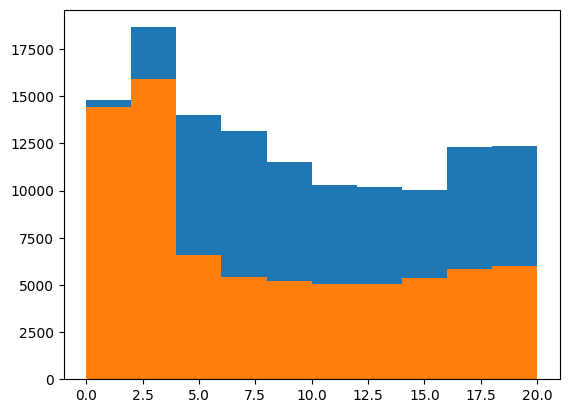

In [6]:
plt.hist(light_dist)
plt.hist(dark_dist)


In [752]:
f_oneway(dark_prob,light_prob)[1]

array([3.72035916e-01, 5.26813065e-05, 3.84002643e-05, 2.62854392e-01,
       1.32612502e-02, 8.68496130e-03, 1.36529281e-02, 4.60552762e-05,
       1.71865988e-05, 2.45456637e-04, 2.68810952e-02, 3.51309138e-02,
       2.58852279e-02, 6.81880693e-02, 1.09042117e-01, 9.59538479e-01,
       1.90034103e-01, 4.74059853e-03, 4.37674489e-03, 3.22386602e-03,
       7.37043093e-02])

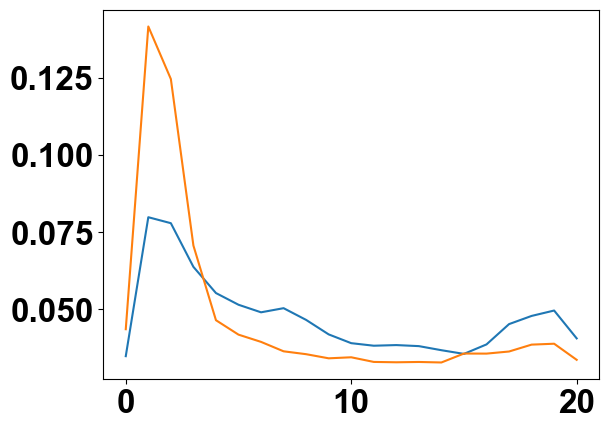

In [748]:
plt.plot(xnew,light_prob.mean(axis=0))
plt.plot(xnew,dark_prob.mean(axis=0))
ax.invert_xaxis()

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


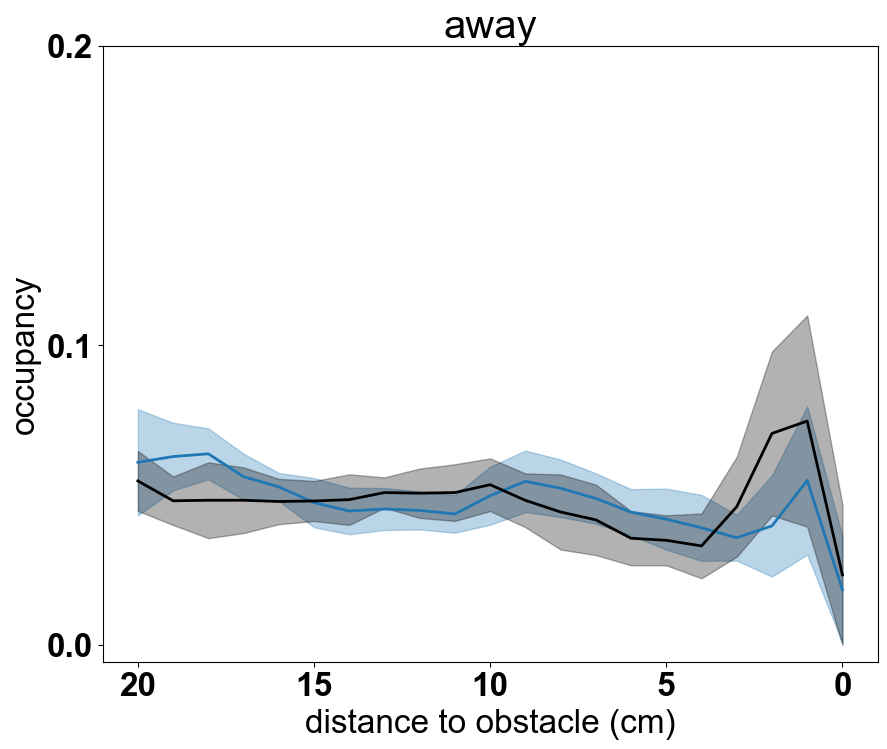

In [864]:
xnew =  np.arange(0, 21, 1)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'away']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    dark_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')   
ax.set_xticks([20,15,10,5,0])  
ax.set_yticks([.20,.1,.0])
ax.set_ylabel('occupancy')  
ax.set_xlabel('distance to obstacle (cm)')
ax.invert_xaxis()
ax.set_title('away')
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\long_occupancy_away.pdf',dpi = 300,transparent=True
            )

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


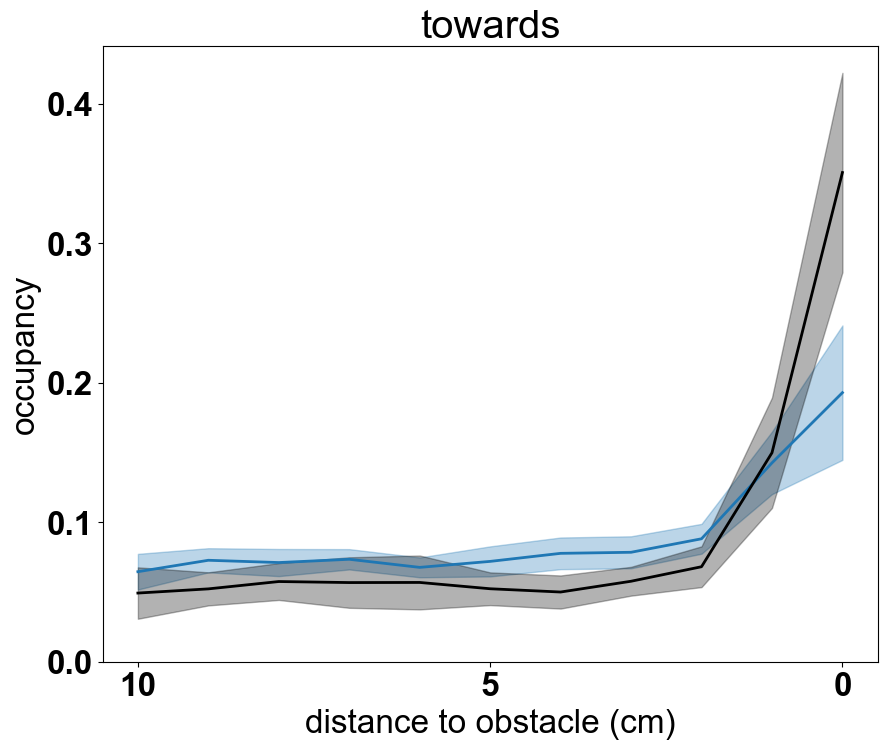

In [865]:
xnew =  np.arange(0, 11, 1)
data = pd.concat([short_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=10))]
light_counts, light_bins = np.histogram(light_dist, bins=11)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=10))]
    counts, bins = np.histogram(ani_light_dists, bins=11)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=10))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=11)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=10))]
    counts, bins = np.histogram(ani_dark_dists, bins=11)
    dark_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')   
ax.set_xticks([10,5,0])  
ax.set_yticks([.4,.3,.20,.1,.0])
ax.set_ylabel('occupancy')  
ax.set_xlabel('distance to obstacle (cm)')
ax.invert_xaxis()
ax.set_title('towards')
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\short_occupancy_towards.pdf',dpi = 300,transparent=True)

In [756]:
(light_counts/sum(light_counts))

array([0.19280827, 0.1424456 , 0.08803951, 0.07835794, 0.07759658,
       0.07182468, 0.06753434, 0.07333711, 0.07099131, 0.07262719,
       0.06443747])

In [758]:
f_oneway(light_prob,dark_prob)[1]

array([1.36469877e-05, 1.20977301e-01, 1.55931056e-02, 2.54069025e-04,
       5.55990029e-05, 1.08804632e-03, 4.52776230e-01, 2.92741245e-02,
       7.51319076e-03, 1.51563309e-06, 6.50685189e-04])

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


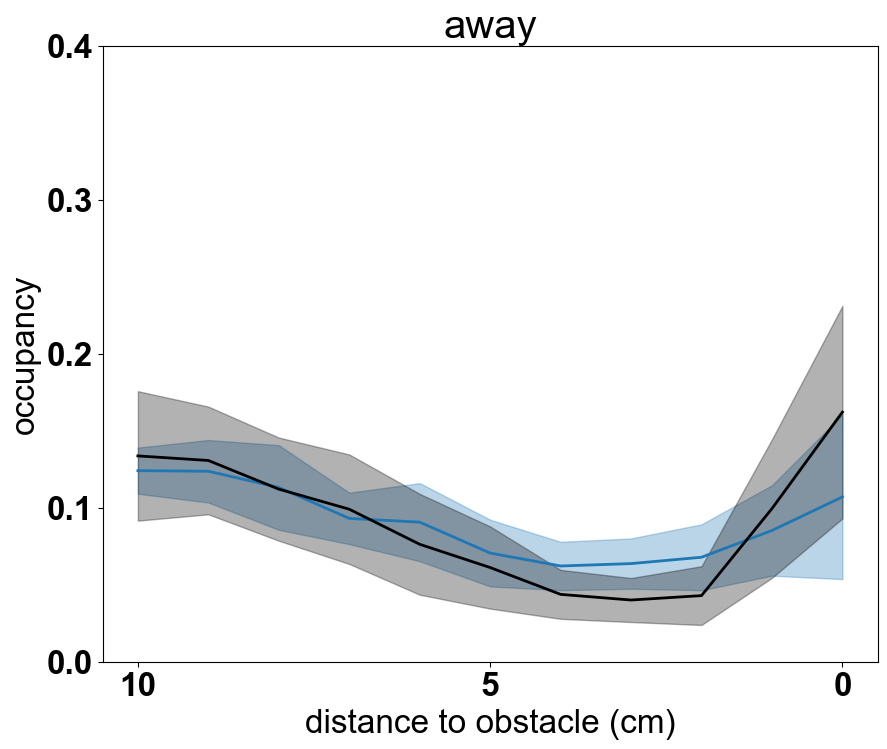

In [866]:
xnew =  np.arange(0, 11, 1)
data = pd.concat([short_nostart])
data = data[data.turn_to_obstacle == 'away']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=10))]
light_counts, light_bins = np.histogram(light_dist, bins=11)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=10))]
    counts, bins = np.histogram(ani_light_dists, bins=11)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=10))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=11)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=10))]
    counts, bins = np.histogram(ani_dark_dists, bins=11)
    dark_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')   
ax.set_xticks([10,5,0])  
ax.set_yticks([.4,.3,.20,.1,.0])
ax.set_ylabel('occupancy')  
ax.set_xlabel('distance to obstacle (cm)')
ax.invert_xaxis()
ax.set_title('away')
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\short_occupancy_away.pdf',dpi = 300,transparent=True)

In [259]:
import random
random.sample(dark.animal.unique().tolist(),3)

['G8CK1TT', 'G8CKRN', 'G8CK1LT']

In [280]:
def ob_tortuosity(df):
    for ind,row in df.iterrows():
        try:
            #target =  np.nanmax(np.argwhere((-1< row['ts_distance_from_edge']) ))
            ob = int(row.obstacle_ind)
            ob_tor,ob_lin= compute_tortuosity(row['ts_nose_x_cm'][:ob],row['ts_nose_y_cm'][:ob])
            df.at[ind,'ob_tortuosity']=ob_tor
            df.at[ind,'ob_linearity']=ob_lin

            goal_tor,goal_lin= compute_tortuosity(row['ts_nose_x_cm'][ob:],row['ts_nose_y_cm'][ob:])
            df.at[ind,'goal_tortuosity']=goal_tor
            df.at[ind,'goal_linearity']=goal_lin
        except ValueError:
            df.at[ind,'ob_tortuosity']=np.nan
            df.at[ind,'ob_linearity']=np.nan
            df.at[ind,'goal_tortuosity']=np.nan
            df.at[ind,'goal_linearity']=np.nan


In [281]:
ob_tortuosity(joint)

Text(0.5, 0, 'path efficiency')

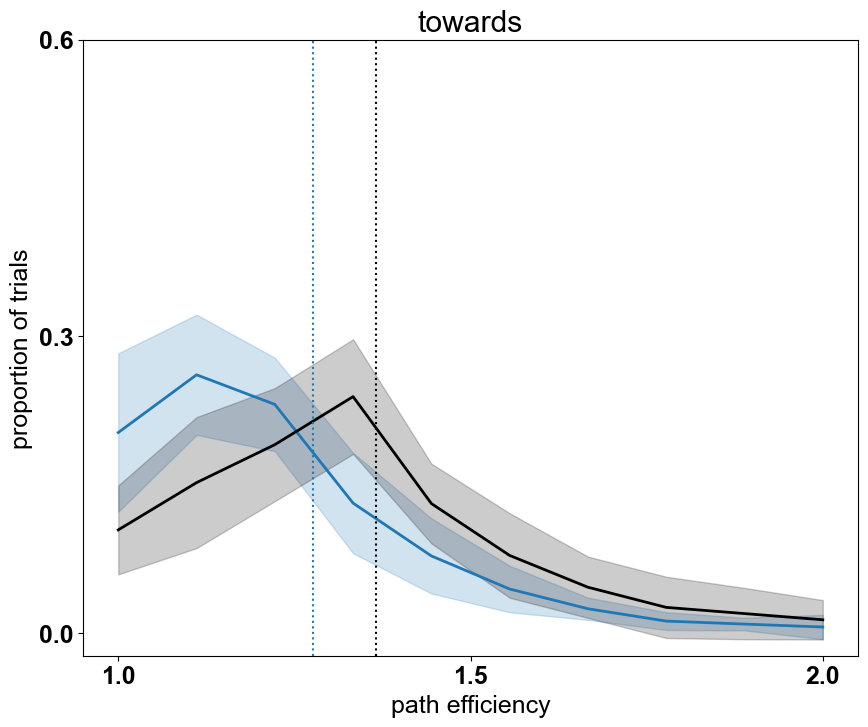

In [ ]:
xnew =  np.linspace(1, 2, 10)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist<=2))]

light_counts, light_bins =np.histogram(light_dist, bins=10)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
light_prob = []
light_mean = []
#light_ani = random.sample(light.animal.unique().tolist(),3)
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=2))]
    
    counts, bins =np.histogram(ani_light_dists, bins=10)
    light_prob.append(counts/sum(counts))
    light_mean.append(np.nanmean(ani_light_dists))
    #if ani in light_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'tab:blue')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_mean = np.asarray(light_mean) 
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.2, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist<=2))]

dark_counts, dark_bins =np.histogram(dark_dist, bins=10)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
dark_prob = []
dark_mean = []
#dark_ani = random.sample(dark.animal.unique().tolist(),3)
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=2))]
    dark_mean.append(np.nanmean(ani_dark_dists))
    counts, bins =np.histogram(ani_dark_dists, bins=10)
    dark_prob.append(counts/sum(counts))
    #if ani in dark_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'black')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_mean = np.asarray(dark_mean) 
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.2, label='IQR')   
ax.set_xticks([1,1.5,2])  
ax.set_yticks([.6,.3,0])
ax.axvline(np.nanmean(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmean(dark_dist), color='black', ls=':')
ax.set_ylabel('proportion of trials')  

ax.set_xlabel('path efficiency')

#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\long_towards_tortuosity.pdf',dpi = 300,transparent=True)

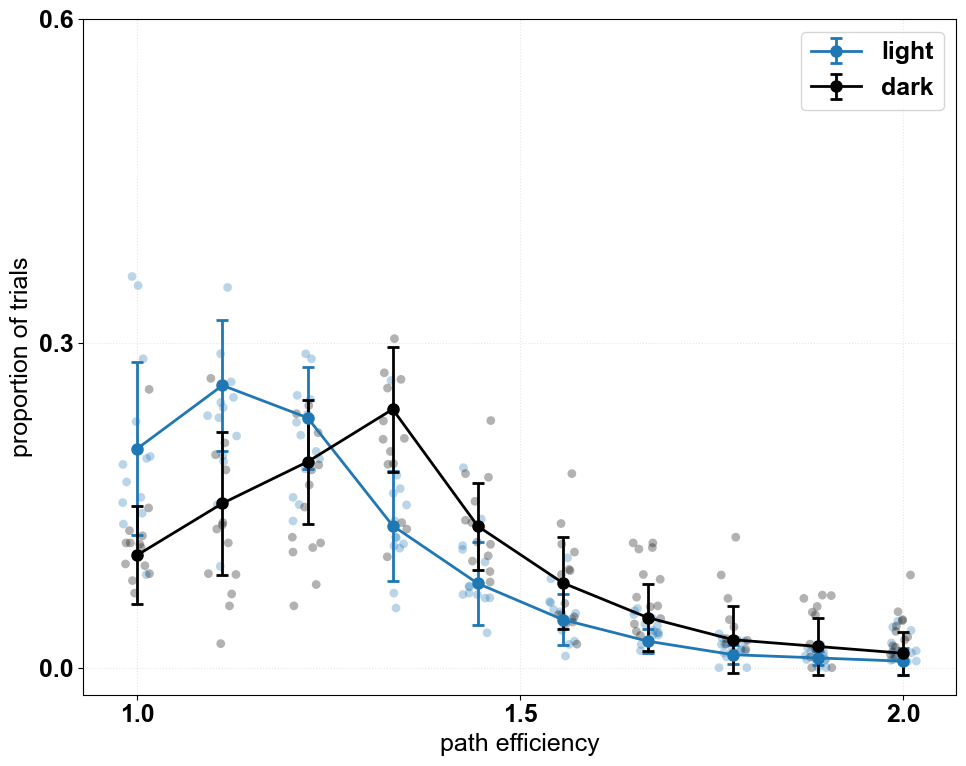

In [37]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Add vertical lines for means


# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.3, 0.6])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('path efficiency', fontweight='normal')     # Not bold

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid lines
ax.grid(True, linestyle=':', alpha=0.3)

# Legend
ax.legend(loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.show()

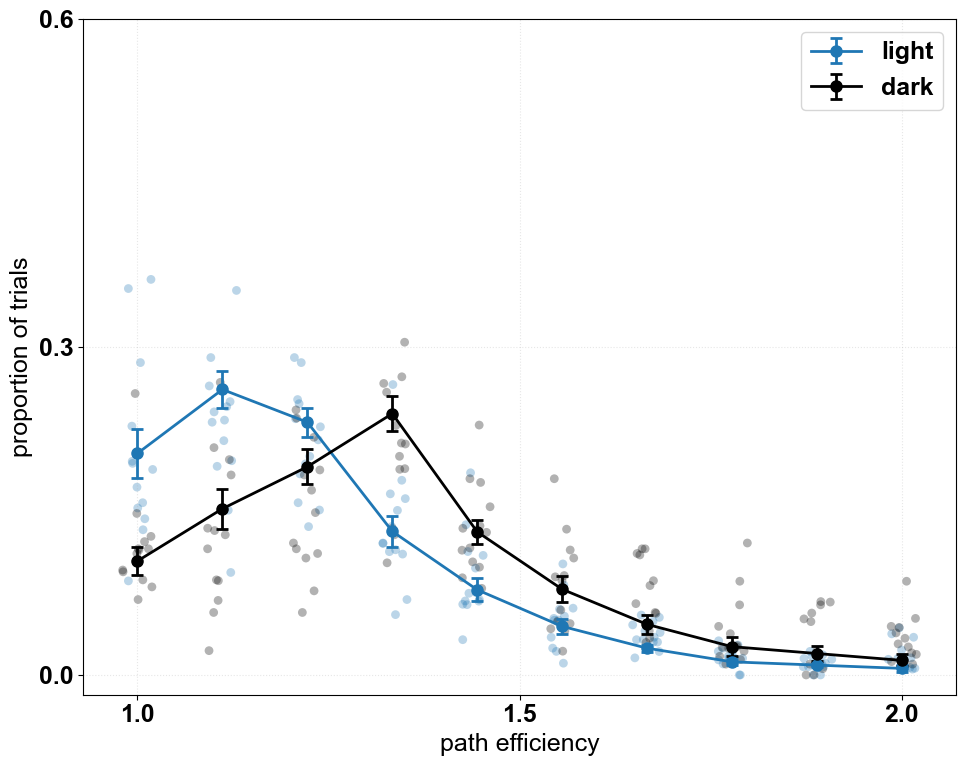

In [46]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.3, 0.6])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('path efficiency', fontweight='normal')     # Not bold

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid lines
ax.grid(True, linestyle=':', alpha=0.3)

# Legend
ax.legend(loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.show()

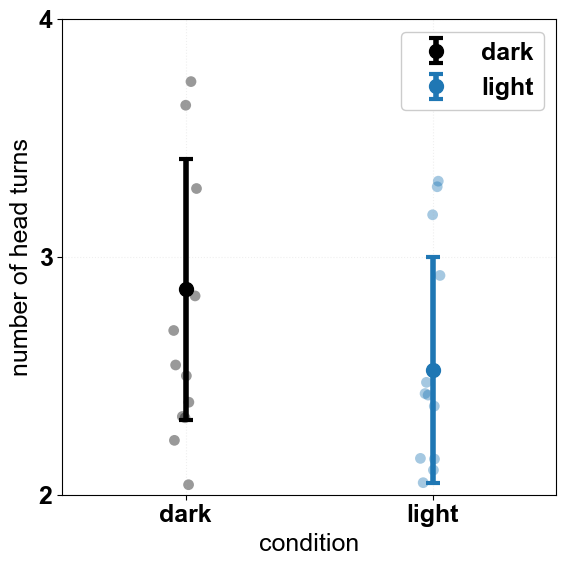

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))

# Set font parameters (normal weight for text)
plt.rcParams.update({
    'font.family': 'arial',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Prepare data
light_data = long[(long.task == 'oa')&(long.turn_to_obstacle == 'towards')]
dark_data = long[(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')]

# Calculate means and std for num_turn
means = {
    'light': light_data.num_turn.mean(),
    'dark': dark_data.num_turn.mean()
}

stds = {
    'light': np.nanstd(light_data.groupby(['animal']).num_turn.mean().to_numpy()),
    'dark': np.nanstd(dark_data.groupby(['animal']).num_turn.mean().to_numpy())
}

# Positions - light on right (position 2), dark on left (position 1)
x_pos = [1, 2]

# Plot individual points with jitter
for i, (name, group) in enumerate([('dark', dark_data), ('light', light_data)]):
    color = 'black' if name == 'dark' else 'tab:blue'
    individual_means = group.groupby(['animal']).num_turn.mean().to_numpy()
    jitter = np.random.uniform(-0.05, 0.05, size=len(individual_means))
    ax.scatter(x_pos[i] + jitter, individual_means,
              color=color, alpha=0.4, s=60, edgecolor='none')

# Plot means and error bars
ax.errorbar(x_pos[0], means['dark'], yerr=stds['dark'],
           fmt='o', color='black', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='dark')

ax.errorbar(x_pos[1], means['light'], yerr=stds['light'],
           fmt='o', color='tab:blue', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='light')

# Formatting
ax.set_xlim(0.5, 2.5)
ax.set_xticks(x_pos, ['dark', 'light'])  # dark on left, light on right
ax.set_ylabel('number of head turns', fontweight='normal')
ax.set_xlabel('condition', fontweight='normal')

# Set exactly 4 y-ticks at 1, 2, 3, 4
ax.set_yticks([ 2, 3, 4])  # Explicitly set ticks at 1, 2, 3, 4
ax.set_ylim(2, 4)  # Ensure the axis range includes all ticks

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid
ax.grid(True, linestyle=':', alpha=0.2)

# Legend
ax.legend(loc='best', framealpha=1)

plt.tight_layout()
plt.show()

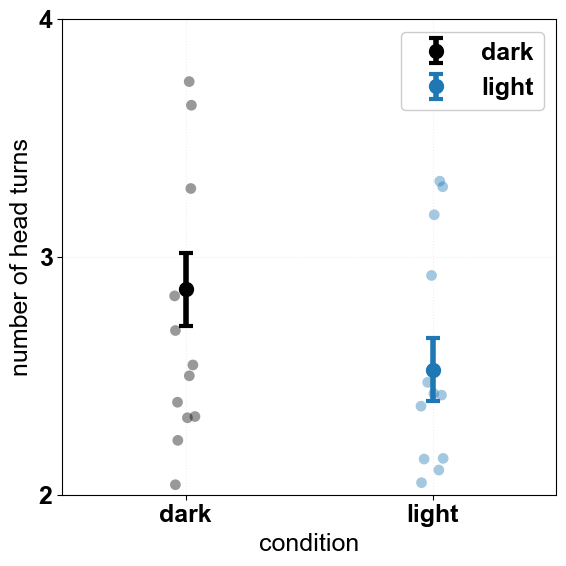

In [51]:
fig, ax = plt.subplots(figsize=(6, 6))

# Set font parameters (normal weight for text)
plt.rcParams.update({
    'font.family': 'arial',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Prepare data
light_data = long[(long.task == 'oa')&(long.turn_to_obstacle == 'towards')]
dark_data = long[(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')]

# Calculate means and SEM for num_turn
means = {
    'light': light_data.num_turn.mean(),
    'dark': dark_data.num_turn.mean()
}

# Calculate SEM (standard error of the mean)
sem = {
    'light': np.nanstd(light_data.groupby(['animal']).num_turn.mean().to_numpy()) / 
             np.sqrt(len(light_data.groupby(['animal']).num_turn.mean())),
    'dark': np.nanstd(dark_data.groupby(['animal']).num_turn.mean().to_numpy()) / 
             np.sqrt(len(dark_data.groupby(['animal']).num_turn.mean()))
}

# Positions - light on right (position 2), dark on left (position 1)
x_pos = [1, 2]

# Plot individual points with jitter
for i, (name, group) in enumerate([('dark', dark_data), ('light', light_data)]):
    color = 'black' if name == 'dark' else 'tab:blue'
    individual_means = group.groupby(['animal']).num_turn.mean().to_numpy()
    jitter = np.random.uniform(-0.05, 0.05, size=len(individual_means))
    ax.scatter(x_pos[i] + jitter, individual_means,
              color=color, alpha=0.4, s=60, edgecolor='none')

# Plot means and error bars with SEM
ax.errorbar(x_pos[0], means['dark'], yerr=sem['dark'],
           fmt='o', color='black', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='dark')

ax.errorbar(x_pos[1], means['light'], yerr=sem['light'],
           fmt='o', color='tab:blue', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='light')

# Formatting
ax.set_xlim(0.5, 2.5)
ax.set_xticks(x_pos, ['dark', 'light'])  # dark on left, light on right
ax.set_ylabel('number of head turns', fontweight='normal')
ax.set_xlabel('condition', fontweight='normal')

# Set exactly 4 y-ticks at 1, 2, 3, 4
ax.set_yticks([2, 3, 4])  # Explicitly set ticks at 1, 2, 3, 4
ax.set_ylim(2, 4)  # Ensure the axis range includes all ticks

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid
ax.grid(True, linestyle=':', alpha=0.2)

# Legend
ax.legend(loc='best', framealpha=1)

plt.tight_layout()
plt.show()

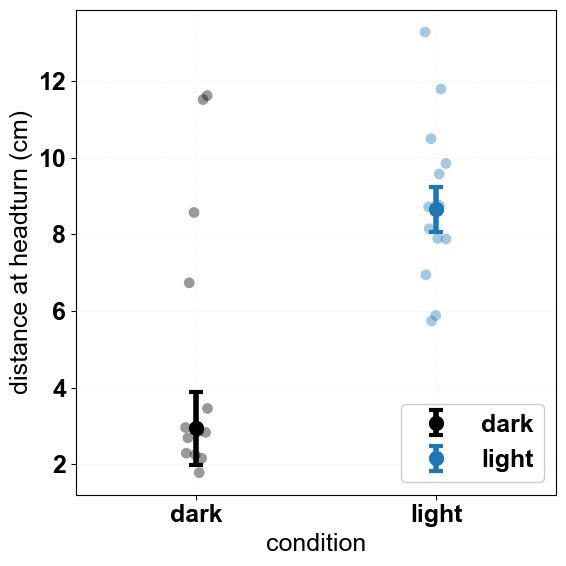

In [49]:
fig, ax = plt.subplots(figsize=(6, 6))

# Set font parameters (normal weight for text)
plt.rcParams.update({
    'font.family': 'arial',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Prepare data
light_data = long[(long.task == 'oa')&(long.turn_to_obstacle == 'towards')]
dark_data = long[(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')]

# Calculate medians and SEM for distance_at_head_turn
medians = {
    'light': light_data.distance_at_head_turn.median(),
    'dark': dark_data.distance_at_head_turn.median()
}

# Calculate SEM (standard error of the mean)
sem = {
    'light': np.nanstd(light_data.groupby(['animal']).distance_at_head_turn.median().to_numpy()) / 
             np.sqrt(len(light_data.groupby(['animal']).distance_at_head_turn.median())),
    'dark': np.nanstd(dark_data.groupby(['animal']).distance_at_head_turn.median().to_numpy()) / 
             np.sqrt(len(dark_data.groupby(['animal']).distance_at_head_turn.median()))
}

# Positions - light on right (position 2), dark on left (position 1)
x_pos = [1, 2]

# Plot individual points with jitter
for i, (name, group) in enumerate([('dark', dark_data), ('light', light_data)]):
    color = 'black' if name == 'dark' else 'tab:blue'
    individual_medians = group.groupby(['animal']).distance_at_head_turn.median().to_numpy()
    jitter = np.random.uniform(-0.05, 0.05, size=len(individual_medians))
    ax.scatter(x_pos[i] + jitter, individual_medians,
              color=color, alpha=0.4, s=60, edgecolor='none')

# Plot medians and error bars with SEM
ax.errorbar(x_pos[0], medians['dark'], yerr=sem['dark'],
           fmt='o', color='black', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='dark')

ax.errorbar(x_pos[1], medians['light'], yerr=sem['light'],
           fmt='o', color='tab:blue', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='light')

# Formatting
ax.set_xlim(0.5, 2.5)
ax.set_xticks(x_pos, ['dark', 'light'])  # dark on left, light on right
ax.set_ylabel('distance at headturn (cm)', fontweight='normal')
ax.set_xlabel('condition', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid
ax.grid(True, linestyle=':', alpha=0.2)

# Legend
ax.legend(loc='best', framealpha=1)

plt.tight_layout()
plt.show()

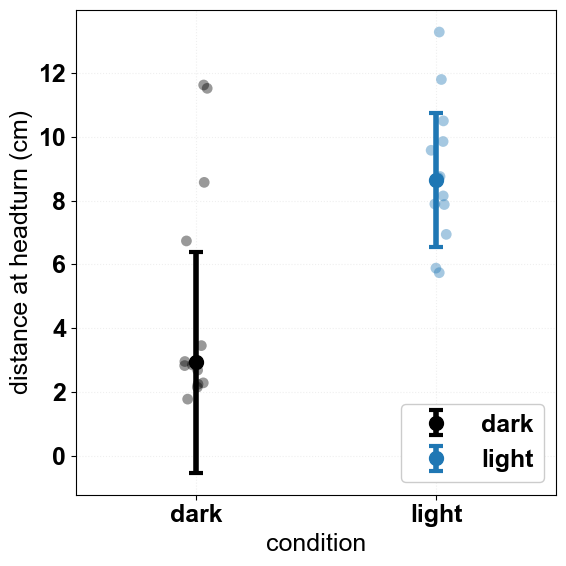

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))

# Set font parameters (normal weight for text)
plt.rcParams.update({
    'font.family': 'arial',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Prepare data
light_data = long[(long.task == 'oa')&(long.turn_to_obstacle == 'towards')]
dark_data = long[(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')]

# Calculate medians and std for distance_at_head_turn
medians = {
    'light': light_data.distance_at_head_turn.median(),
    'dark': dark_data.distance_at_head_turn.median()
}

stds = {
    'light': np.nanstd(light_data.groupby(['animal']).distance_at_head_turn.median().to_numpy()),
    'dark': np.nanstd(dark_data.groupby(['animal']).distance_at_head_turn.median().to_numpy())
}

# Positions - light on right (position 2), dark on left (position 1)
x_pos = [1, 2]

# Plot individual points with jitter
for i, (name, group) in enumerate([('dark', dark_data), ('light', light_data)]):
    color = 'black' if name == 'dark' else 'tab:blue'
    individual_medians = group.groupby(['animal']).distance_at_head_turn.median().to_numpy()
    jitter = np.random.uniform(-0.05, 0.05, size=len(individual_medians))
    ax.scatter(x_pos[i] + jitter, individual_medians,
              color=color, alpha=0.4, s=60, edgecolor='none')

# Plot medians and error bars
ax.errorbar(x_pos[0], medians['dark'], yerr=stds['dark'],
           fmt='o', color='black', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='dark')

ax.errorbar(x_pos[1], medians['light'], yerr=stds['light'],
           fmt='o', color='tab:blue', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='light')

# Formatting
ax.set_xlim(0.5, 2.5)
ax.set_xticks(x_pos, ['dark', 'light'])  # dark on left, light on right
ax.set_ylabel('distance at headturn (cm)', fontweight='normal')
ax.set_xlabel('condition', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid
ax.grid(True, linestyle=':', alpha=0.2)

# Legend
ax.legend(loc='best', framealpha=1)

plt.tight_layout()
plt.show()

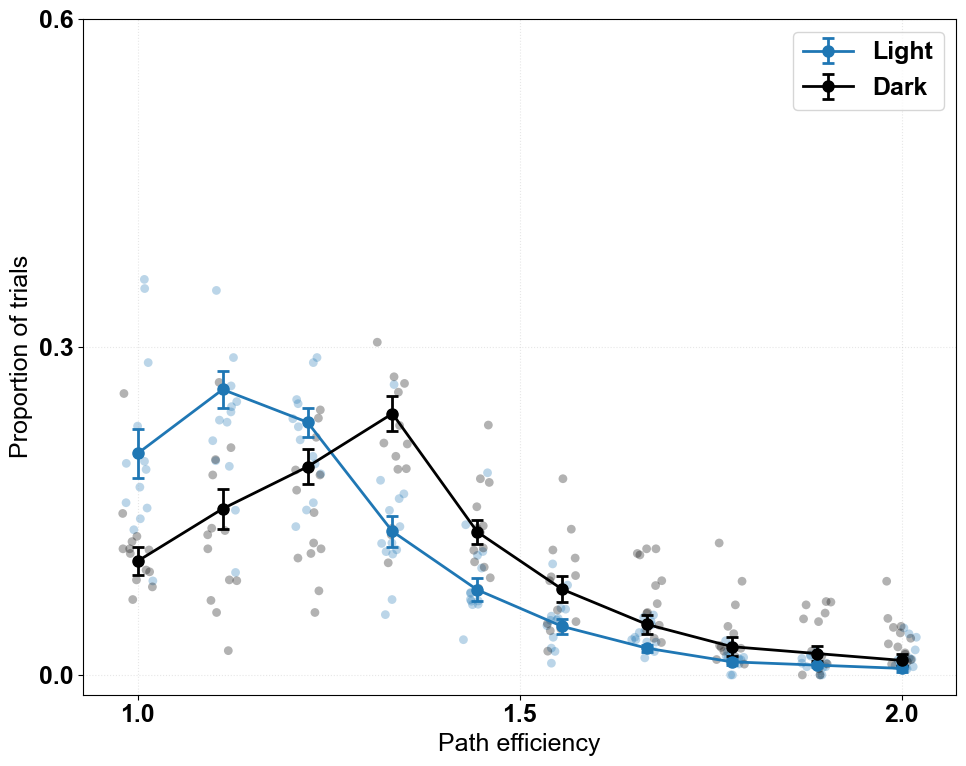

In [48]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_n = np.sum(~np.isnan(light_prob), axis=0)  # Number of non-NaN observations
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(light_n)

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_n = np.sum(~np.isnan(dark_prob), axis=0)  # Number of non-NaN observations
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(dark_n)

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='Light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='Dark')

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.3, 0.6])
ax.set_ylabel('Proportion of trials', fontweight='normal')
ax.set_xlabel('Path efficiency', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid lines
ax.grid(True, linestyle=':', alpha=0.3)

# Legend
ax.legend(loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.show()

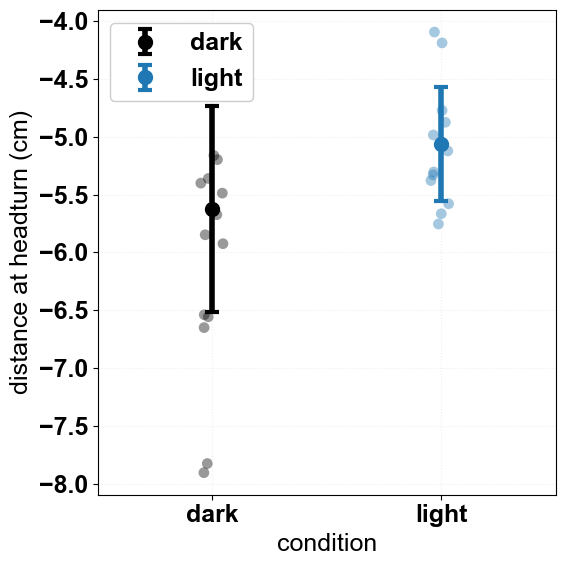

In [39]:
fig, ax = plt.subplots(figsize=(6, 6))

# Set font parameters (normal weight for text)
plt.rcParams.update({
    'font.family': 'arial',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Prepare data
light_data = long[(long.task == 'oa')&(long.turn_to_obstacle == 'towards')]
dark_data = long[(long.task == 'oadark')&(long.turn_to_obstacle == 'towards')]

# Calculate medians and std for head_corner_angle_velocity_at_head_turn
medians = {
    'light': light_data.head_corner_angle_velocity_at_head_turn.median(),
    'dark': dark_data.head_corner_angle_velocity_at_head_turn.median()
}

stds = {
    'light': np.nanstd(light_data.groupby(['animal']).head_corner_angle_velocity_at_head_turn.median().to_numpy()),
    'dark': np.nanstd(dark_data.groupby(['animal']).head_corner_angle_velocity_at_head_turn.median().to_numpy())
}

# Positions - light on right (position 2), dark on left (position 1)
x_pos = [1, 2]

# Plot individual points with jitter
for i, (name, group) in enumerate([('dark', dark_data), ('light', light_data)]):
    color = 'black' if name == 'dark' else 'tab:blue'
    individual_medians = group.groupby(['animal']).head_corner_angle_velocity_at_head_turn.median().to_numpy()
    jitter = np.random.uniform(-0.05, 0.05, size=len(individual_medians))
    ax.scatter(x_pos[i] + jitter, individual_medians,
              color=color, alpha=0.4, s=60, edgecolor='none')

# Plot medians and error bars
ax.errorbar(x_pos[0], medians['dark'], yerr=stds['dark'],
           fmt='o', color='black', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='dark')

ax.errorbar(x_pos[1], medians['light'], yerr=stds['light'],
           fmt='o', color='tab:blue', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='light')

# Formatting
ax.set_xlim(0.5, 2.5)
ax.set_xticks(x_pos, ['dark', 'light'])  # dark on left, light on right
ax.set_ylabel('distance at headturn (cm)', fontweight='normal')
ax.set_xlabel('condition', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid
ax.grid(True, linestyle=':', alpha=0.2)

# Legend
ax.legend(loc='best', framealpha=1)

plt.tight_layout()
plt.show()

In [38]:
list_columns(long,['velocity'])

array(['head_angle_velocity', 'head_corner_angle_velocity',
       'intial_head_angle_velocity',
       'head_corner_angle_velocity_at_head_turn'], dtype='<U39')

(array([133., 194., 243., 305., 167., 100.,  59.,  33.,  25.,  17.]),
 array([1.0430635 , 1.13802756, 1.23299162, 1.32795567, 1.42291973,
        1.51788378, 1.61284784, 1.7078119 , 1.80277595, 1.89774001,
        1.99270406]),
 <BarContainer object of 10 artists>)

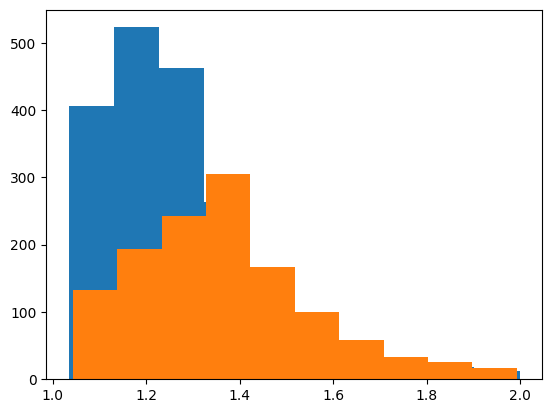

In [9]:
plt.hist(light_dist)
plt.hist(dark_dist)

Text(0.5, 0, '')

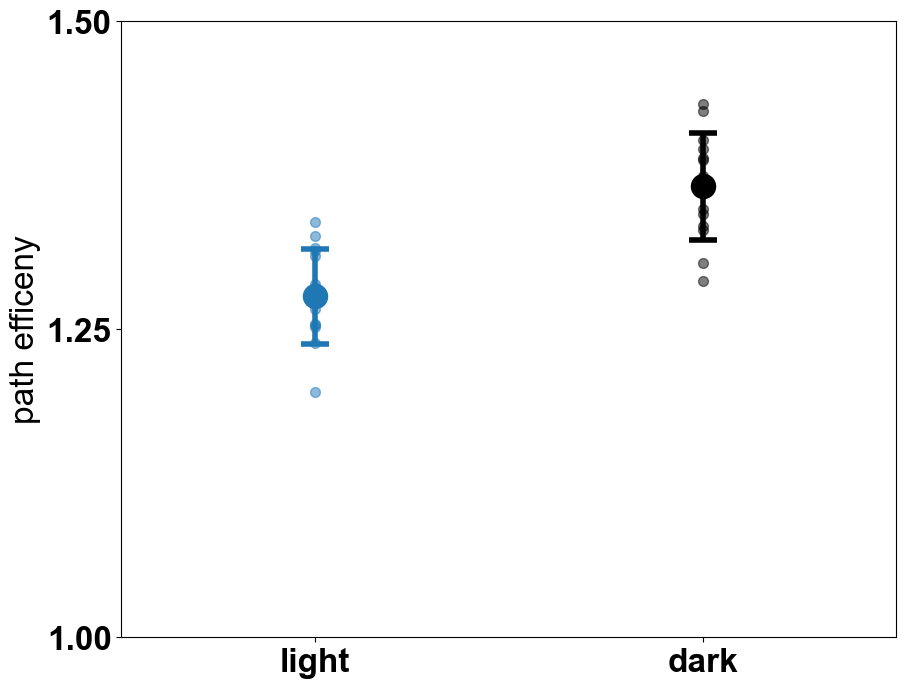

In [835]:
fig,ax = plt.subplots(figsize=(10,8))
data = long_nostart

data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]
data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()\

ax.scatter(0,light_mean,color = 'tab:blue',s = 300)

ax.scatter(1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([0],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],0),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)

ax.set_xticks([-.5,0,1,1.5])

ax.set_xticklabels(['',0,1,''])
ax.set_yticks([1,1.25,1.5])
ax.set_xticks([0,1],['light','dark'])

ax.set_ylabel('path efficeny')
ax.set_xlabel('')

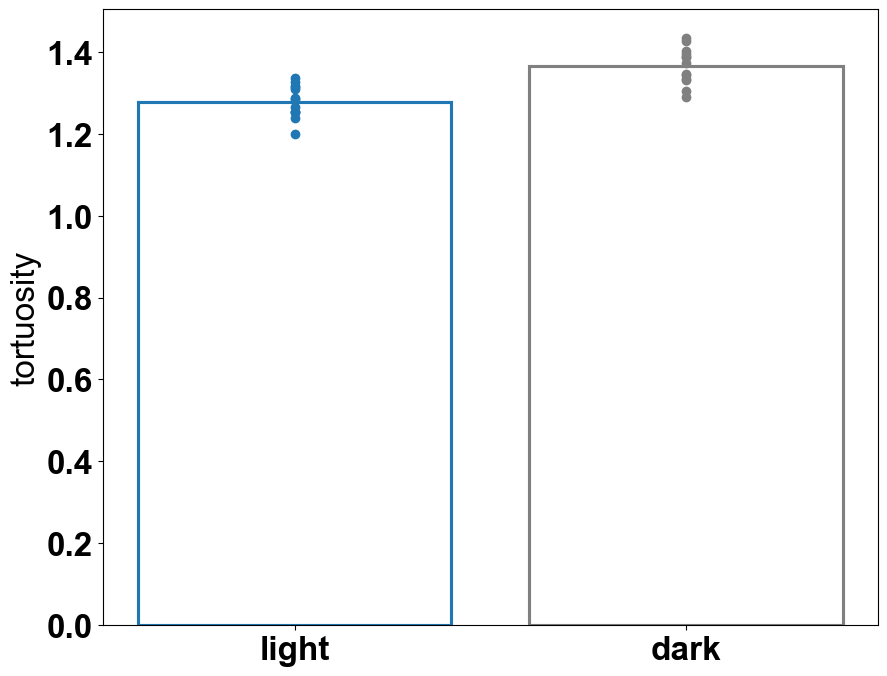

In [799]:
fig,ax = plt.subplots(figsize=(10,8))
data = long_nostart

data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]
data = data[data.tortuosity >=.2]




sns.barplot(ax = ax, data = data ,x='task' ,y = 'tortuosity',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None,fill=False) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('tortuosity')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])



light = data[data.task == 'oa']
#light = light[light.time<=10]
light_median = light.tortuosity.mean()
light_after= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())

dark = data[data.task == 'oadark']
#dark = dark[dark.time<=10]
dark_median = dark.tortuosity.mean()
dark_after= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())




#ax.errorbar([0,1],[light_median,dark_median] , yerr=[light_after,dark_after], ls='none' ,color="black",)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],0),light.groupby(['animal']).tortuosity.mean().to_numpy())
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='grey')

In [829]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]
#data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
light_mean= light.groupby(['animal']).tortuosity.mean().to_numpy()
dark_mean= dark.groupby(['animal']).tortuosity.mean().to_numpy()
f_oneway(light_mean,dark_mean)

F_onewayResult(statistic=26.471409699862217, pvalue=2.8797192131054355e-05)

In [588]:
from scipy.stats import tukey_hsd
print(tukey_hsd(light_mean,dark_mean))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.086     0.000    -0.121    -0.052
 (1 - 0)      0.086     0.000     0.052     0.121



meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


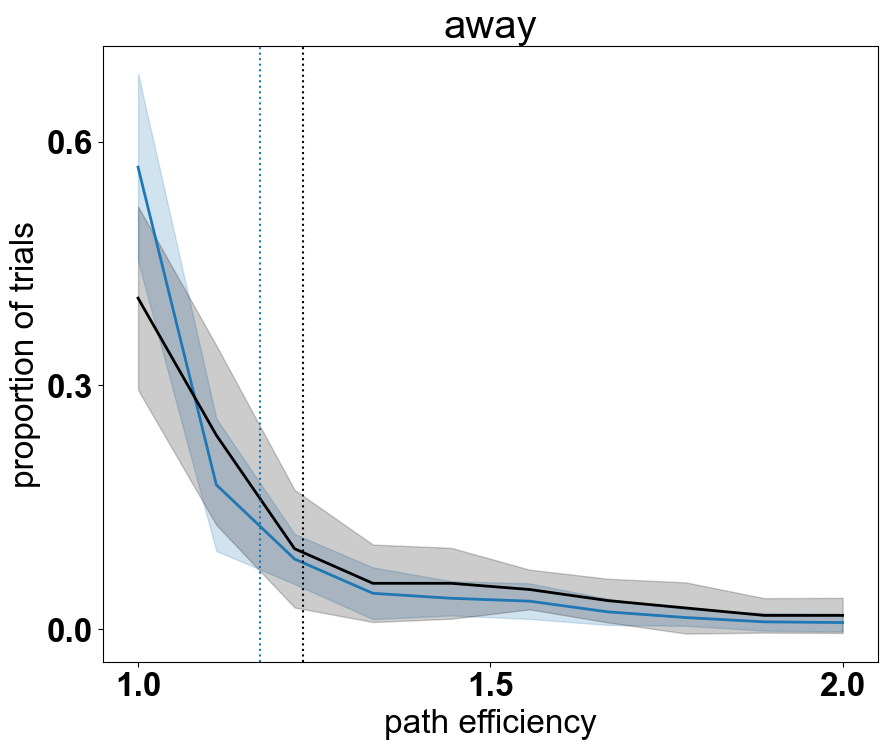

In [862]:
xnew =  np.linspace(1,2,10)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'away']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist<=2))]

light_counts, light_bins =np.histogram(light_dist, bins=10)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
light_prob = []
light_mean = []
light_ani = random.sample(light.animal.unique().tolist(),3)
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=2))]
    
    counts, bins =np.histogram(ani_light_dists, bins=10)
    light_prob.append(counts/sum(counts))
    light_mean.append(np.nanmean(ani_light_dists))
    #if ani in light_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'tab:blue')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_mean = np.asarray(light_mean) 
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.2, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist<=2))]

dark_counts, dark_bins =np.histogram(dark_dist, bins=10)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
dark_prob = []
dark_mean = []
dark_ani = random.sample(dark.animal.unique().tolist(),3)
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=2))]
    dark_mean.append(np.nanmean(ani_dark_dists))
    counts, bins =np.histogram(ani_dark_dists, bins=10)
    dark_prob.append(counts/sum(counts))
    #if ani in dark_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'black')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_mean = np.asarray(dark_mean) 
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.2, label='IQR')   
#ax.set_xticks([20,15,10,5,0])  
#ax.set_yticks([.3,.15,0])
ax.set_xticks([1,1.5,2])  
ax.set_yticks([.6,.3,0])
ax.axvline(np.nanmean(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmean(dark_dist), color='black', ls=':')
ax.set_ylabel('proportion of trials')  
ax.set_title('away')
ax.set_xlabel('path efficiency')


fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\long_away_tortuosity.pdf',dpi = 300,transparent=True)

Text(0.5, 0, '')

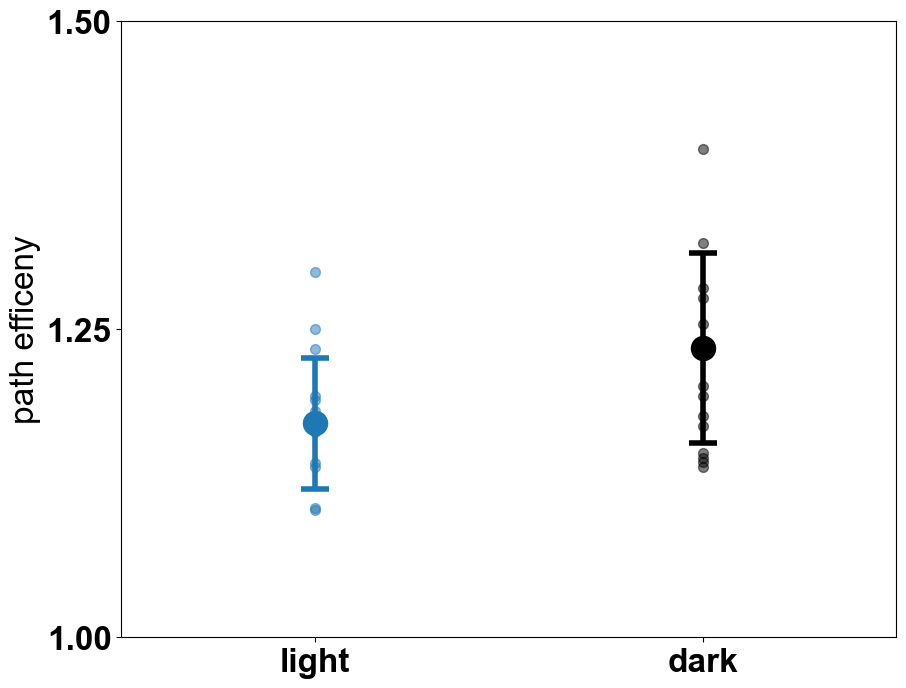

In [836]:
fig,ax = plt.subplots(figsize=(10,8))
data = long_nostart

data = data[data.turn_to_obstacle == 'away']
data = data[data.tortuosity <=2]
data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()\

ax.scatter(0,light_mean,color = 'tab:blue',s = 300)

ax.scatter(1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([0],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],0),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)

ax.set_xticks([-.5,0,1,1.5])

ax.set_xticklabels(['',0,1,''])
ax.set_yticks([1,1.25,1.5])
ax.set_xticks([0,1],['light','dark'])

ax.set_ylabel('path efficeny')
ax.set_xlabel('')

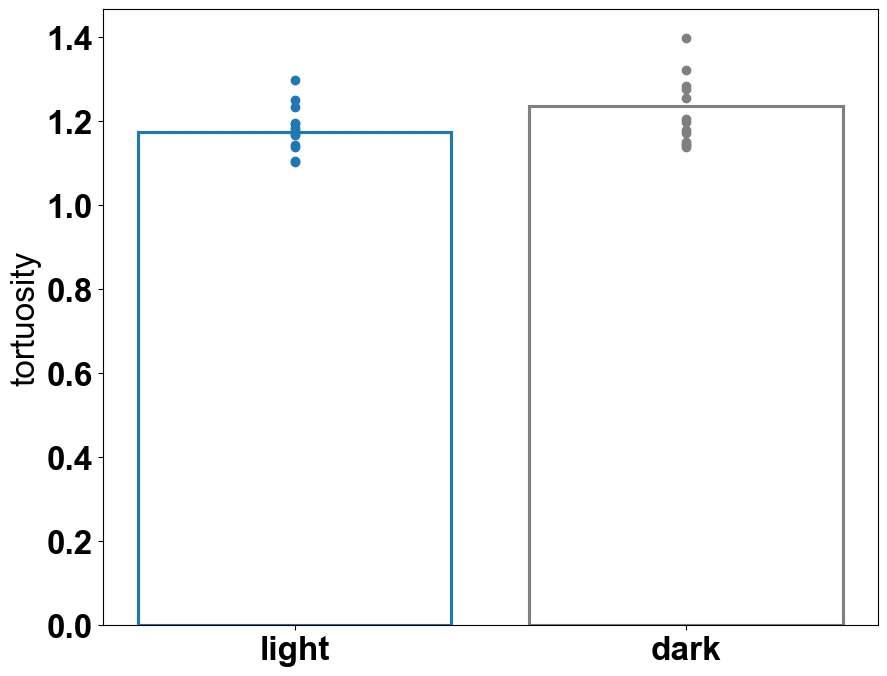

In [567]:
fig,ax = plt.subplots(figsize=(10,8))
data = long_nostart

data = data[data.turn_to_obstacle == 'away']
data = data[data.tortuosity <=2]



sns.barplot(ax = ax, data = data ,x='task' ,y = 'tortuosity',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None,fill=False) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('tortuosity')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])



light = data[data.task == 'oa']
#light = light[light.time<=10]
light_median = light.tortuosity.mean()
light_after= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())

dark = data[data.task == 'oadark']
#dark = dark[dark.time<=10]
dark_median = dark.tortuosity.mean()
dark_after= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())

#ax.errorbar([0,1],[light_median,dark_median] , yerr=[light_after,dark_after], ls='none' ,color="black",)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],0),light.groupby(['animal']).tortuosity.mean().to_numpy())
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='grey')

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


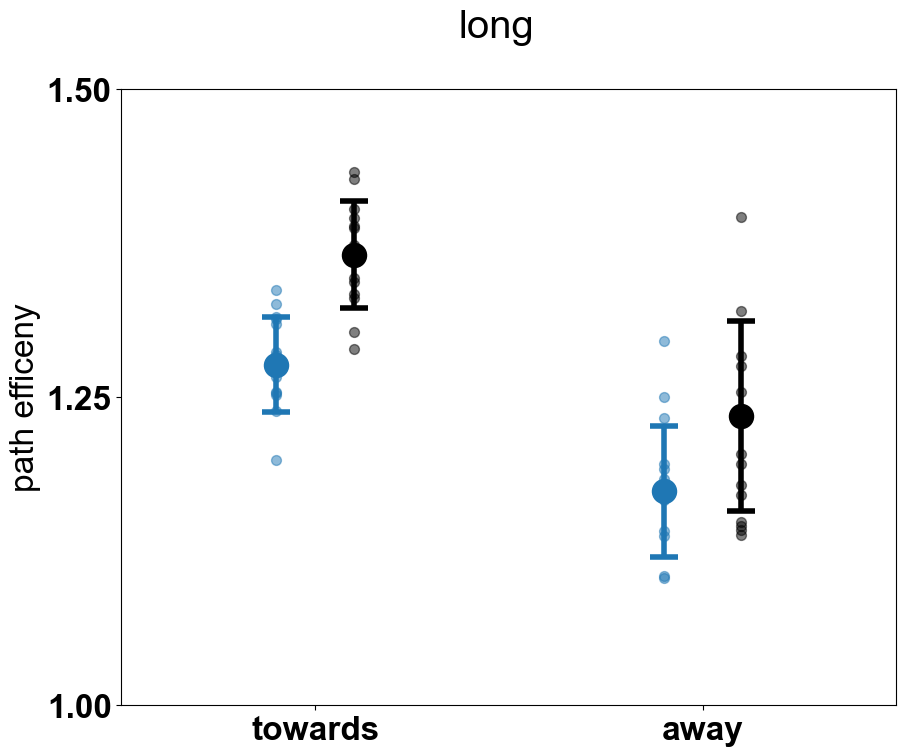

In [860]:
fig,ax = plt.subplots(figsize=(10,8))
data = long_nostart

data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]
data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()

ax.scatter(-.1,light_mean,color = 'tab:blue',s = 300)

ax.scatter(.1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([-.1],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([.1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],-.1),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],.1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)


data = long_nostart
data = data[data.turn_to_obstacle == 'away']
data = data[data.tortuosity <=2]
data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()

ax.scatter(.9,light_mean,color = 'tab:blue',s = 300)

ax.scatter(1.1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([.9],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([1.1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],.9),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1.1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)

ax.set_xticks([-.5,0,1,1.5])

ax.set_xticklabels(['',0,1,''])
ax.set_yticks([1,1.25,1.5])
ax.set_xticks([0,1],['towards','away'])

ax.set_ylabel('path efficeny')
ax.set_xlabel('')
fig.suptitle('long')


fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\long_tortuosity_mean.pdf',dpi = 300,transparent=True)

In [850]:
data = short_nostart
data = data[data.turn_to_obstacle == 'away']
data = data[data.tortuosity <=2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
light_mean= light.groupby(['animal']).tortuosity.mean().to_numpy()
dark_mean= dark.groupby(['animal']).tortuosity.mean().to_numpy()
f_oneway(light_mean,dark_mean)

F_onewayResult(statistic=0.06691385859344358, pvalue=0.7980899853579106)

In [851]:
from scipy.stats import tukey_hsd
print(tukey_hsd(light_mean,dark_mean))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.006     0.798    -0.054     0.042
 (1 - 0)      0.006     0.798    -0.042     0.054



meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


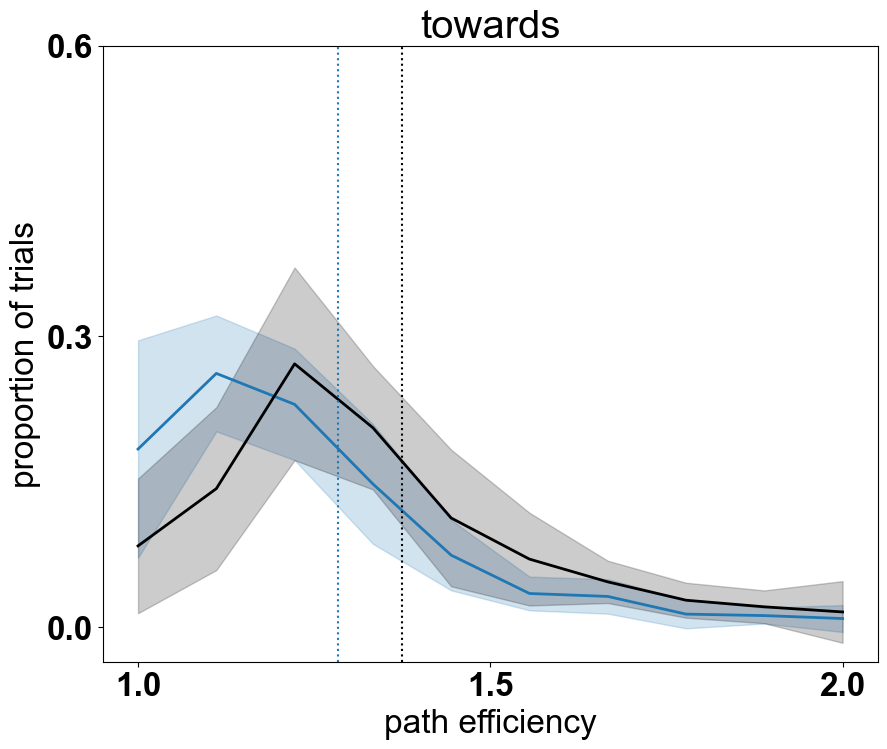

In [874]:
xnew =  np.linspace(1,2,10)
data = pd.concat([short_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist<=2))]

light_counts, light_bins =np.histogram(light_dist, bins=10)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
light_prob = []
light_median = []
light_ani = random.sample(light.animal.unique().tolist(),3)
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=2))]
    
    counts, bins =np.histogram(ani_light_dists, bins=10)
    light_prob.append(counts/sum(counts))
    light_median.append(np.nanmean(ani_light_dists))
    #if ani in light_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'tab:blue')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_median = np.asarray(light_median) 
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.2, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist<=2))]

dark_counts, dark_bins =np.histogram(dark_dist, bins=10)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
dark_prob = []
dark_median = []
dark_ani = random.sample(dark.animal.unique().tolist(),3)
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=2))]
    dark_median.append(np.nanmean(ani_dark_dists))
    counts, bins =np.histogram(ani_dark_dists, bins=10)
    dark_prob.append(counts/sum(counts))
    #if ani in dark_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'black')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_median = np.asarray(dark_median) 
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.2, label='IQR')   
ax.set_xticks([1,1.5,2])  
ax.set_yticks([.6,.3,0])
ax.axvline(np.nanmean(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmean(dark_dist), color='black', ls=':')
ax.set_ylabel('proportion of trials')  
ax.set_title('towards')
ax.set_xlabel('path efficiency')


fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\towards_short_tortuosity_mean.pdf',dpi = 300,transparent=True)

Text(0.5, 0, '')

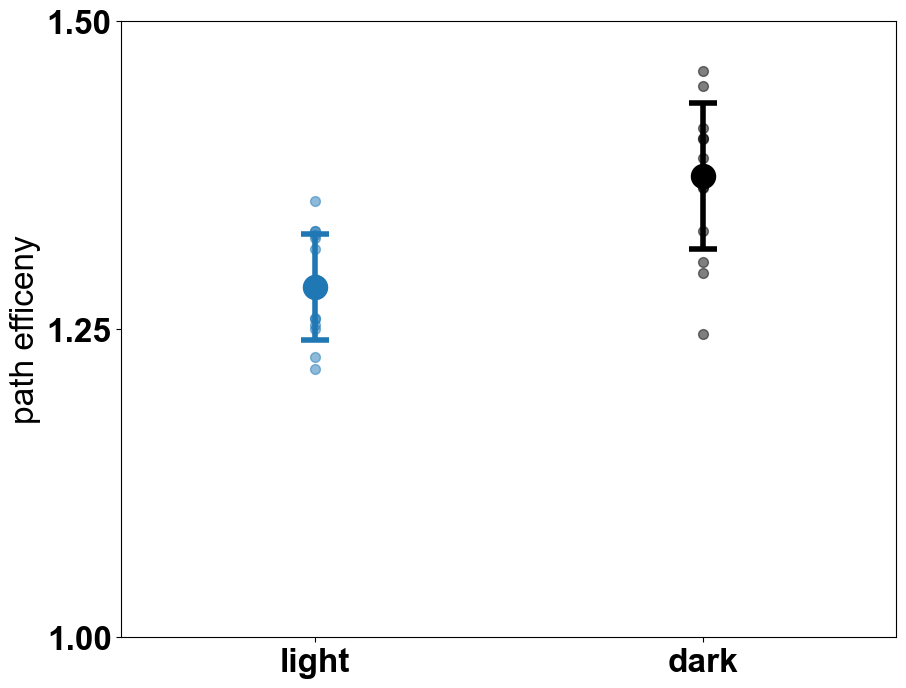

In [837]:
fig,ax = plt.subplots(figsize=(10,8))
data = short_nostart

data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]
#data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()\

ax.scatter(0,light_mean,color = 'tab:blue',s = 300)

ax.scatter(1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([0],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],0),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)

ax.set_xticks([-.5,0,1,1.5])

ax.set_xticklabels(['',0,1,''])
ax.set_yticks([1,1.25,1.5])
ax.set_xticks([0,1],['light','dark'])

ax.set_ylabel('path efficeny')
ax.set_xlabel('')

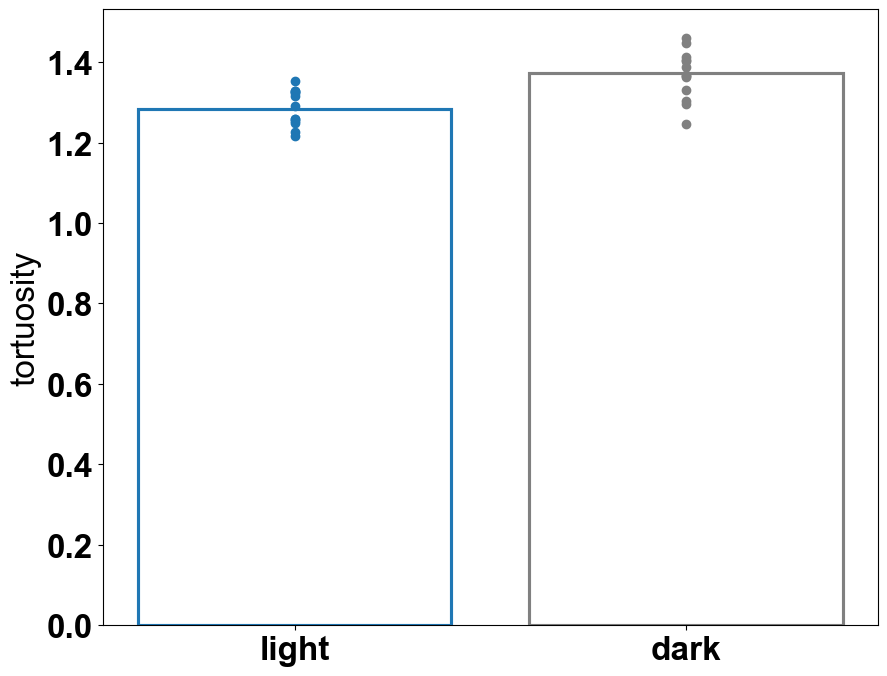

In [574]:
fig,ax = plt.subplots(figsize=(10,8))
data = short_nostart

data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]



sns.barplot(ax = ax, data = data ,x='task' ,y = 'tortuosity',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None,fill=False) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('tortuosity')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])



light = data[data.task == 'oa']
#light = light[light.time<=10]
light_median = light.tortuosity.mean()
light_after= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())

dark = data[data.task == 'oadark']
#dark = dark[dark.time<=10]
dark_median = dark.tortuosity.mean()
dark_after= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())

#ax.errorbar([0,1],[light_median,dark_median] , yerr=[light_after,dark_after], ls='none' ,color="black",)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],0),light.groupby(['animal']).tortuosity.mean().to_numpy())
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='grey')

In [573]:
data = short_nostart
data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
light_mean= light.groupby(['animal']).tortuosity.mean().to_numpy()
dark_mean= dark.groupby(['animal']).tortuosity.mean().to_numpy()
f_oneway(light_mean,dark_mean)

F_onewayResult(statistic=14.759773386521926, pvalue=0.0007850213041857111)

In [582]:
light_mean.mean()

1.2796334350122867

In [583]:
dark_mean.mean()

1.3658521492649713

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


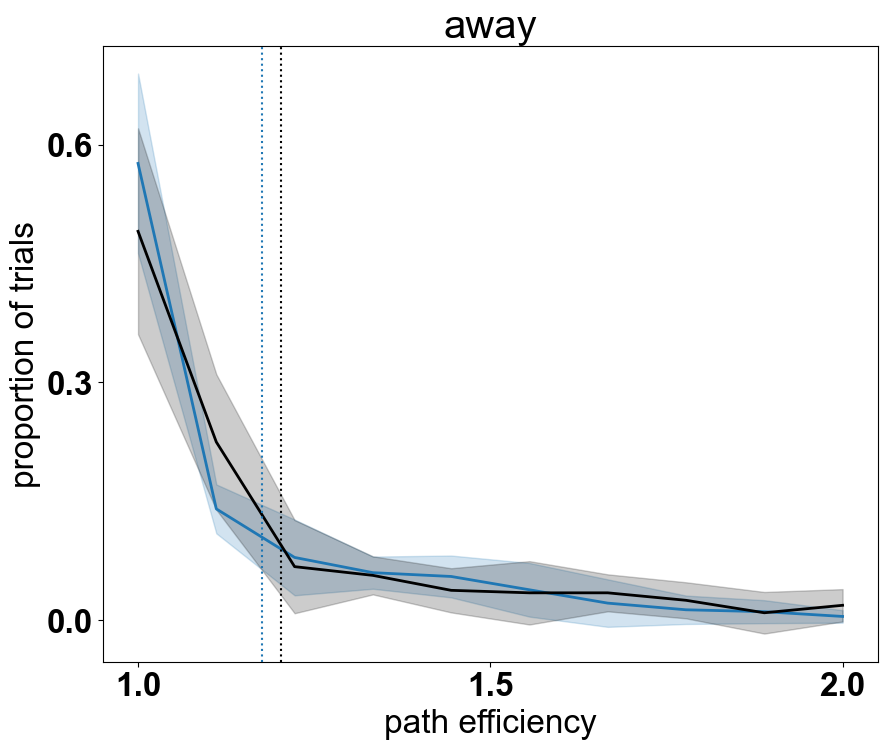

In [875]:
xnew =  np.linspace(1,2,10)
data = pd.concat([short_nostart])
data = data[data.turn_to_obstacle == 'away']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist<=2))]

light_counts, light_bins =np.histogram(light_dist, bins=10)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
light_prob = []
light_median = []
light_ani = random.sample(light.animal.unique().tolist(),3)
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=2))]
    
    counts, bins =np.histogram(ani_light_dists, bins=10)
    light_prob.append(counts/sum(counts))
    light_median.append(np.nanmean(ani_light_dists))
    #if ani in light_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'tab:blue')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_median = np.asarray(light_median) 
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.2, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist<=2))]

dark_counts, dark_bins =np.histogram(dark_dist, bins=10)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
dark_prob = []
dark_median = []
dark_ani = random.sample(dark.animal.unique().tolist(),3)
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=2))]
    dark_median.append(np.nanmean(ani_dark_dists))
    counts, bins =np.histogram(ani_dark_dists, bins=10)
    dark_prob.append(counts/sum(counts))
    #if ani in dark_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'black')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_median = np.asarray(dark_median) 
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.2, label='IQR')   
ax.set_xticks([1,1.5,2])  
ax.set_yticks([.6,.3,0])
ax.axvline(np.nanmean(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmean(dark_dist), color='black', ls=':')
ax.set_ylabel('proportion of trials')  
ax.set_title('away')
ax.set_xlabel('path efficiency')


fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\away_short_tortuosity_mean.pdf',dpi = 300,transparent=True)

Text(0.5, 0, '')

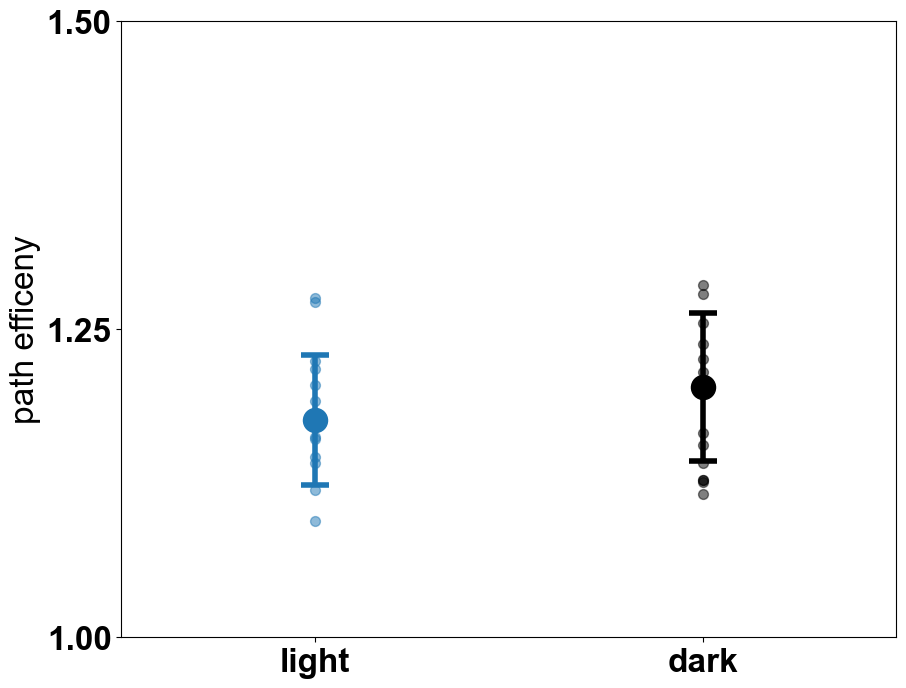

In [838]:
fig,ax = plt.subplots(figsize=(10,8))
data = short_nostart

data = data[data.turn_to_obstacle == 'away']
data = data[data.tortuosity <=2]
#data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()\

ax.scatter(0,light_mean,color = 'tab:blue',s = 300)

ax.scatter(1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([0],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],0),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)

ax.set_xticks([-.5,0,1,1.5])

ax.set_xticklabels(['',0,1,''])
ax.set_yticks([1,1.25,1.5])
ax.set_xticks([0,1],['light','dark'])

ax.set_ylabel('path efficeny')
ax.set_xlabel('')

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


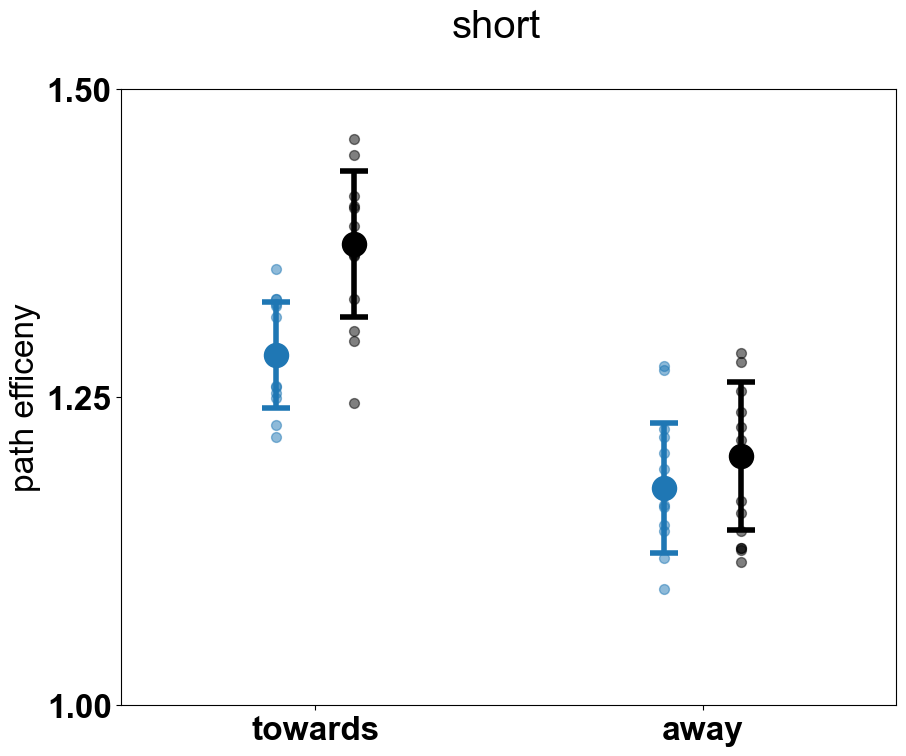

In [873]:
fig,ax = plt.subplots(figsize=(10,8))
data = short_nostart

data = data[data.turn_to_obstacle == 'towards']
data = data[data.tortuosity <=2]
data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()

ax.scatter(-.1,light_mean,color = 'tab:blue',s = 300)

ax.scatter(.1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([-.1],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([.1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],-.1),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],.1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)


data = short_nostart
data = data[data.turn_to_obstacle == 'away']
data = data[data.tortuosity <=2]
data = data[data.tortuosity >=.2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']

light_mean = light.tortuosity.mean()
dark_mean = dark.tortuosity.mean()

ax.scatter(.9,light_mean,color = 'tab:blue',s = 300)

ax.scatter(1.1,dark_mean,color = 'black',s = 300)



light_std= np.nanstd(light.groupby(['animal']).tortuosity.mean().to_numpy())
dark_std= np.nanstd(dark.groupby(['animal']).tortuosity.mean().to_numpy())


ax.errorbar([.9],[light_mean] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)

ax.errorbar([1.1],[dark_mean] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],.9),light.groupby(['animal']).tortuosity.mean().to_numpy(),color='tab:blue',alpha=.5,s=50)
ax.scatter(np.full(dark.groupby(['animal']).tortuosity.mean().to_numpy().shape[0],1.1),dark.groupby(['animal']).tortuosity.mean().to_numpy(),color='black',alpha=.5,s=50)

ax.set_xticks([-.5,0,1,1.5])

ax.set_xticklabels(['',0,1,''])
ax.set_yticks([1,1.25,1.5])
ax.set_xticks([0,1],['towards','away'])

ax.set_ylabel('path efficeny')
#ax.set_xlabel('')
fig.suptitle('short')

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\short_tortuosity_mean.pdf',dpi = 300,transparent=True)

<AxesSubplot: >

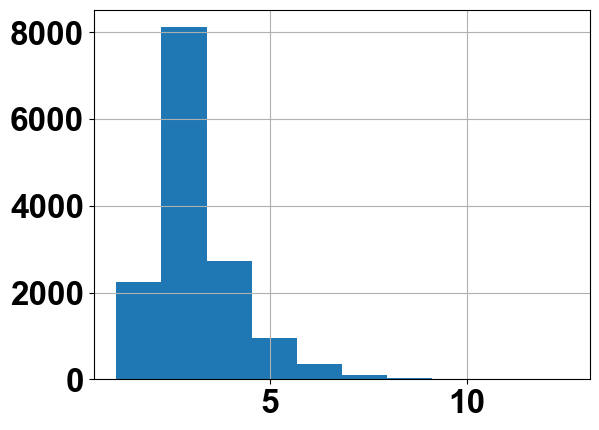

In [763]:
joint.time.hist()

In [794]:
long_nostart['ts_total_distance'<10]

TypeError: '<' not supported between instances of 'str' and 'int'

In [786]:
flatten_list_of_arrays(long_nostart['ts_speed']

8        [7.071956994694936, 6.749018983866641, 6.21477...
12       [9.822642677461742, 9.218571870018433, 8.18906...
17       [12.759453262434718, 12.703284230032292, 12.59...
22       [19.961481201984014, 18.964656214917433, 17.23...
24       [24.689999986349655, 25.077373710579984, 25.84...
                               ...                        
14500    [34.49597291316476, 34.87258490076654, 35.5761...
14515    [41.02777108770284, 41.42085458439077, 42.1203...
14523    [31.56728469068168, 31.54732876027397, 31.4796...
14535    [35.92695671287116, 36.25711384684219, 36.8711...
14547    [39.88940910637285, 40.571484980719546, 41.772...
Name: ts_speed, Length: 5295, dtype: object

In [795]:
light_bins

array([45.75106876, 51.10780336, 56.46453797, 61.82127257, 67.17800717,
       72.53474178, 77.89147638, 83.24821099, 88.60494559, 93.9616802 ,
       99.3184148 ])

Text(0.5, 1.0, 'long')

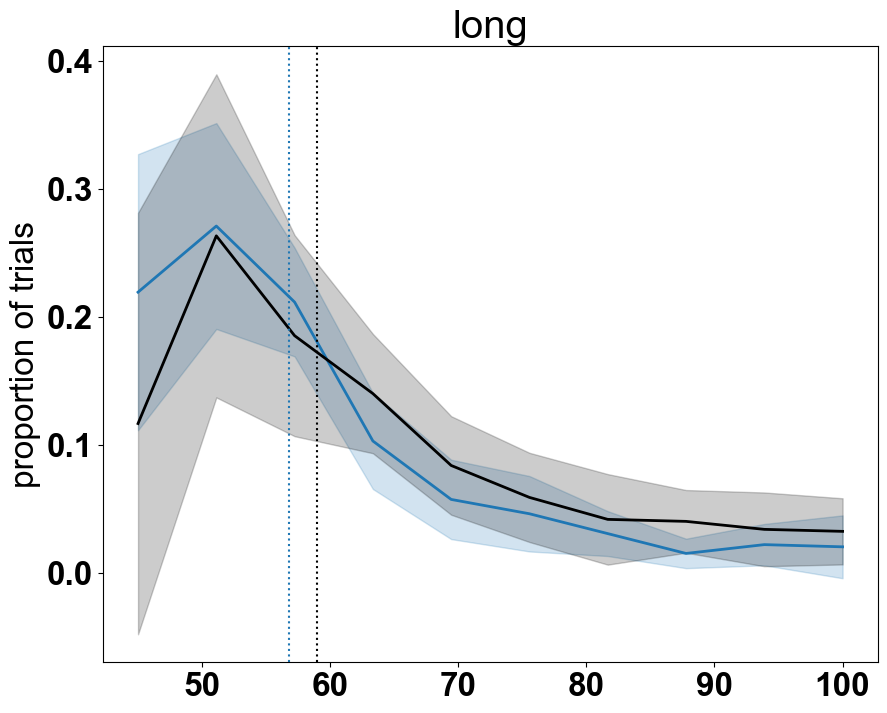

In [798]:
xnew =  np.linspace(45,100,10)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'away']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.ts_total_distance.to_numpy())
light_dist = light_dist[np.where((light_dist<=100))]

light_counts, light_bins =np.histogram(light_dist, bins=10)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
light_prob = []
light_median = []

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.ts_total_distance.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=100))]
    
    counts, bins =np.histogram(ani_light_dists, bins=10)
    light_prob.append(counts/sum(counts))
    light_median.append(np.nanmedian(ani_light_dists))
    #if ani in light_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'tab:blue')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_median = np.asarray(light_median) 
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.2, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.ts_total_distance.to_numpy())
dark_dist = dark_dist[np.where((dark_dist<=100))]

dark_counts, dark_bins =np.histogram(dark_dist, bins=10)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
dark_prob = []
dark_median = []
dark_ani = random.sample(dark.animal.unique().tolist(),3)
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.ts_total_distance.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=100))]
    dark_median.append(np.nanmedian(ani_dark_dists))
    counts, bins =np.histogram(ani_dark_dists, bins=10)
    dark_prob.append(counts/sum(counts))
    #if ani in dark_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'black')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_median = np.asarray(dark_median) 
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.2, label='IQR')   
#ax.set_xticks([20,15,10,5,0])  
#ax.set_yticks([.3,.15,0])
ax.axvline(np.nanmedian(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_dist), color='black', ls=':')
ax.set_ylabel('proportion of trials')  
ax.set_title('long')

Text(0.5, 1.0, 'long')

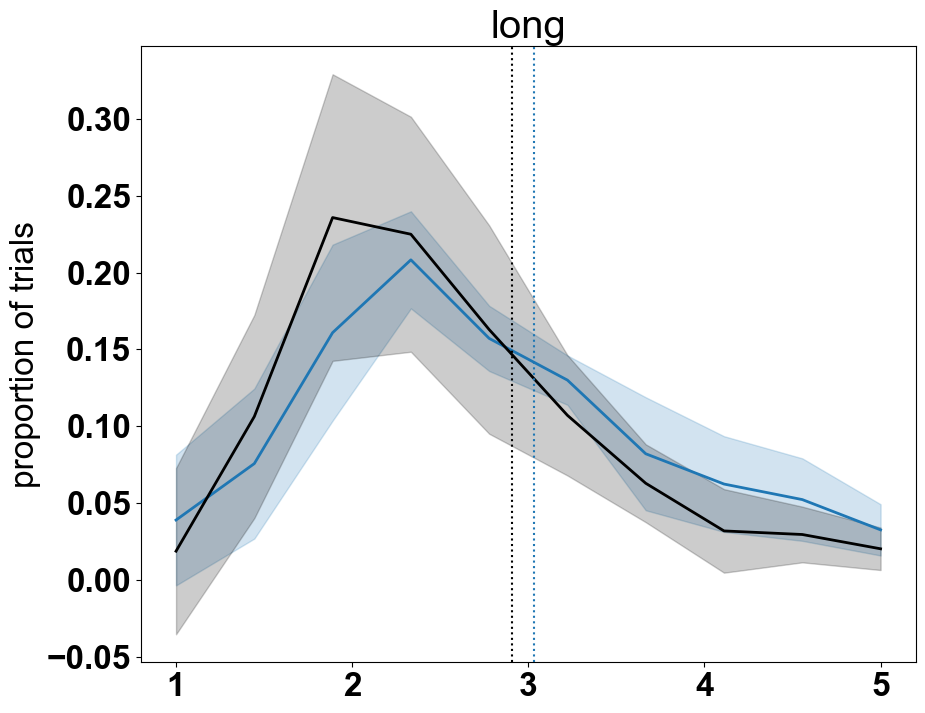

In [789]:
xnew =  np.linspace(1,5,10)
data = pd.concat([long_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.time.to_numpy())
light_dist = light_dist[np.where((light_dist<=5))]

light_counts, light_bins =np.histogram(light_dist, bins=10)
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
light_prob = []
light_median = []

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.time.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=5))]
    
    counts, bins =np.histogram(ani_light_dists, bins=10)
    light_prob.append(counts/sum(counts))
    light_median.append(np.nanmean(ani_light_dists))
    #if ani in light_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'tab:blue')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_median = np.asarray(light_median) 
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.2, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.time.to_numpy())
dark_dist = dark_dist[np.where((dark_dist<=5))]

dark_counts, dark_bins =np.histogram(dark_dist, bins=10)
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
dark_prob = []
dark_median = []
dark_ani = random.sample(dark.animal.unique().tolist(),3)
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.time.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=5))]
    dark_median.append(np.nanmean(ani_dark_dists))
    counts, bins =np.histogram(ani_dark_dists, bins=10)
    dark_prob.append(counts/sum(counts))
    #if ani in dark_ani:
        #ax.plot(xnew, (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'black')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_median = np.asarray(dark_median) 
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.2, label='IQR')   
#ax.set_xticks([20,15,10,5,0])  
#ax.set_yticks([.3,.15,0])
ax.axvline(np.nanmean(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmean(dark_dist), color='black', ls=':')
ax.set_ylabel('proportion of trials')  
ax.set_title('long')

Text(0.5, 1.0, 'short')

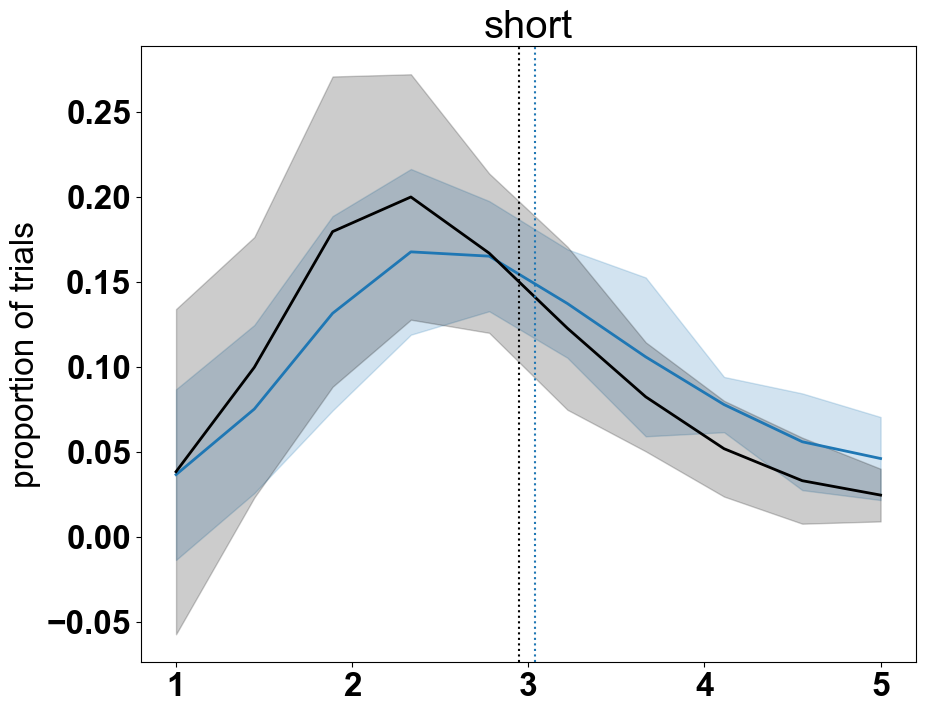

In [771]:
xnew =  np.linspace(1,5,10)
data = pd.concat([short_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.time.to_numpy())
light_dist = light_dist[np.where((light_dist<=5))]

light_counts, light_bins =np.histogram(light_dist, bins=10)
ax.plot(xnew, smooth(light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
light_prob = []
light_median = []
light_ani = random.sample(light.animal.unique().tolist(),3)
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.time.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=5))]
    
    counts, bins =np.histogram(ani_light_dists, bins=10)
    light_prob.append(counts/sum(counts))
    light_median.append(np.nanmean(ani_light_dists))
    #if ani in light_ani:
        #ax.plot(xnew, smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'tab:blue')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_median = np.asarray(light_median) 
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, smooth(light_counts/sum(light_counts))-light_sd, smooth(light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.2, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.time.to_numpy())
dark_dist = dark_dist[np.where((dark_dist<=5))]

dark_counts, dark_bins =np.histogram(dark_dist, bins=10)
ax.plot(xnew, smooth(dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:1], counts, alpha=0.5, label='Fill')
dark_prob = []
dark_median = []
dark_ani = random.sample(dark.animal.unique().tolist(),3)
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.time.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=5))]
    dark_median.append(np.nanmean(ani_dark_dists))
    counts, bins =np.histogram(ani_dark_dists, bins=10)
    dark_prob.append(counts/sum(counts))
    #if ani in dark_ani:
        #ax.plot(xnew, smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.3,color = 'black')
    #ax[0].fill_between(bins[:1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_median = np.asarray(dark_median) 
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.fill_between(xnew, smooth(dark_counts/sum(dark_counts))-dark_sd, smooth(dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.2, label='IQR')   
#ax.set_xticks([20,15,10,5,0])  
#ax.set_yticks([.3,.15,0])
ax.axvline(np.nanmean(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmean(dark_dist), color='black', ls=':')
ax.set_ylabel('proportion of trials')  
ax.set_title('short')

In [578]:
data = short_nostart
data = data[data.turn_to_obstacle == 'away']
data = data[data.tortuosity <=2]

light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
light_mean= light.groupby(['animal']).tortuosity.mean().to_numpy()
dark_mean= dark.groupby(['animal']).tortuosity.mean().to_numpy()
f_oneway(light_mean,dark_mean)

F_onewayResult(statistic=0.06691385859344358, pvalue=0.7980899853579106)

In [349]:
def proportion_of_strings(lst, target_strings):
    """Calculates the proportion of certain strings in a list.

    Args:
        lst (list): The list of strings.
        target_strings (list): The strings to calculate the proportion for.

    Returns:
        dict: A dictionary with the proportions of each target string.
    """

    total_count = len(lst)
    proportions = {}

    for target in target_strings:
        count = lst.count(target)
        proportions[target] = count / total_count

    return proportions

In [354]:
light = long_nostart[long_nostart.task =='oa']

In [359]:
light.turn_to_obstacle.unique().tolist()

['towards', 'away']

In [592]:
light = middle_nostart[middle_nostart.task =='oa']
my_list = light.turn_to_obstacle.to_list()
proportion_of_strings(my_list, light.turn_to_obstacle.unique().tolist())

{'towards': 0.0771227289581016,
 'away': 0.8839451242120875,
 nan: 0.0003707823507601038}

In [608]:
light = long_nostart[long_nostart.task =='oa']
light = light[light.date_index ==5]
my_list = light.turn_to_obstacle.to_list()
proportion_of_strings(my_list, light.turn_to_obstacle.unique().tolist())

{'towards': 0.5958762886597938, 'away': 0.4041237113402062}

In [600]:
light = middle_nostart[middle_nostart.task =='oa']
my_list = light.turn_direction.to_list()
proportion_of_strings(my_list, light.turn_direction.unique().tolist())

{'up': 0.4779384501297738, 'down': 0.5220615498702261}

In [584]:
light = short_nostart[short_nostart.task =='oa']
my_list = light.turn_to_obstacle.to_list()
proportion_of_strings(my_list, light.turn_to_obstacle.unique().tolist())

{'towards': 0.7033723331039229, 'away': 0.29662766689607706}

In [585]:
light = long_nostart[long_nostart.task =='oadark']
my_list = light.turn_to_obstacle.to_list()
proportion_of_strings(my_list, light.turn_to_obstacle.unique().tolist())

{'away': 0.3415964303420922, 'towards': 0.6584035696579078}

In [370]:
light = short_nostart[short_nostart.task =='oadark']
my_list = light.turn_to_obstacle.to_list()
proportion_of_strings(my_list, light.turn_to_obstacle.unique().tolist())

{'away': 0.3229571984435798, 'towards': 0.6770428015564203}

In [350]:
my_list = ["apple", "banana", "apple", "cherry", "banana", "apple"]
target_strings = ["apple", "banana"]

proportions = proportion_of_strings(my_list, target_strings)
print(proportions)

{'apple': 0.5, 'banana': 0.3333333333333333}


In [609]:
def intial_lateral_error(df):
    for ind, row in df.itterows():
        intial_lateral_error = row.lateral_error[0]
        df.at[ind,'intial_lateral_error'] = intial_lateral_error

In [ ]:
def turn_to_obstacle2(df):
    for ind,row in df.iterrows():
        if (row.obstacle_cluster ==  2) or  (row.obstacle_cluster ==  3):
            if (row.start=='top') & (row.turn_direction=='up'):
                df.at[ind,'turn_to_obstacle'] = 'away'
            if (row.start=='top') & (row.turn_direction=='down'):
                df.at[ind,'turn_to_obstacle'] = 'towards'
            if (row.start=='bottom') & (row.turn_direction=='down'):
                df.at[ind,'turn_to_obstacle'] = 'away'
            if (row.start=='bottom') & (row.turn_direction=='up'):
                df.at[ind,'turn_to_obstacle'] = 'towards'
        elif (row.obstacle_cluster ==  0) or  (row.obstacle_cluster ==  1):
            if row.turn_direction == 'up':
                df.at[ind,'turn_to_obstacle'] = 'towards'
            else:
                df.at[ind,'turn_to_obstacle'] = 'away'
        elif (row.obstacle_cluster ==  4) or  (row.obstacle_cluster ==  5):
            if row.turn_direction == 'up':
                df.at[ind,'turn_to_obstacle'] = 'away'
            else:
                df.at[ind,'turn_to_obstacle'] = 'towards'

In [34]:
row.intial_lateral_error

-8.364247809328065

In [33]:
sns.countplot(data = joint ,x= 'task',y = 'turn_to_obstacle')

TypeError: Cannot pass values for both `x` and `y`.